<a href="https://colab.research.google.com/github/fpinell/hands_on_python_for_ds/blob/main/notebooks/master/2026/Lecture_4_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Sample dataset
df = pd.DataFrame({
    'size':      ['M', 'L', 'S', 'XL', 'M', 'S'],
    'education': ['bachelor', 'phd', 'high_school', 'master', 'bachelor', 'master'],
    'rating':    ['good', 'excellent', 'poor', 'good', 'excellent', 'poor'],
})


In [5]:
df.head()

,size,education,rating
0,M,bachelor,good
1,L,phd,excellent
2,S,high_school,poor
3,XL,master,good
4,M,bachelor,excellent


In [6]:

# Define the ordering of each column's categories (lowest -> highest)
size_order      = ['S', 'M', 'L', 'XL']
education_order = ['high_school', 'bachelor', 'master', 'phd']
rating_order    = ['poor', 'good', 'excellent']

# IMPORTANT: the list of categories must match the order of the columns
# you pass to fit_transform
cols       = ['size', 'education', 'rating']
categories = [size_order, education_order, rating_order]

encoder = OrdinalEncoder(categories=categories)
df[cols] = encoder.fit_transform(df[cols])

print(df)
print("\nLearned categories:")
for col, cats in zip(cols, encoder.categories_):
    print(f"  {col}: {list(cats)}")

   size  education  rating
0   1.0        1.0     1.0
1   2.0        3.0     2.0
2   0.0        0.0     0.0
3   3.0        2.0     1.0
4   1.0        1.0     2.0
5   0.0        2.0     0.0

Learned categories:
  size: ['S', 'M', 'L', 'XL']
  education: ['high_school', 'bachelor', 'master', 'phd']
  rating: ['poor', 'good', 'excellent']


A few notes:

- The categories argument takes a list of lists, one per column, in the same order as the columns you pass to fit_transform. Each inner list defines the ranking — the first element maps to 0.0, the next to 1.0, and so on.
- If you have unseen categories at transform time, add handle_unknown='use_encoded_value', unknown_value=-1 (or np.nan) to avoid errors.
- If you want integer output instead of float, pass dtype=int to the constructor.
- For columns where you don't care about order, categories='auto' (the default) uses sorted unique values — but then ```LabelEncoder``` or ```OneHotEncoder``` is often more appropriate.

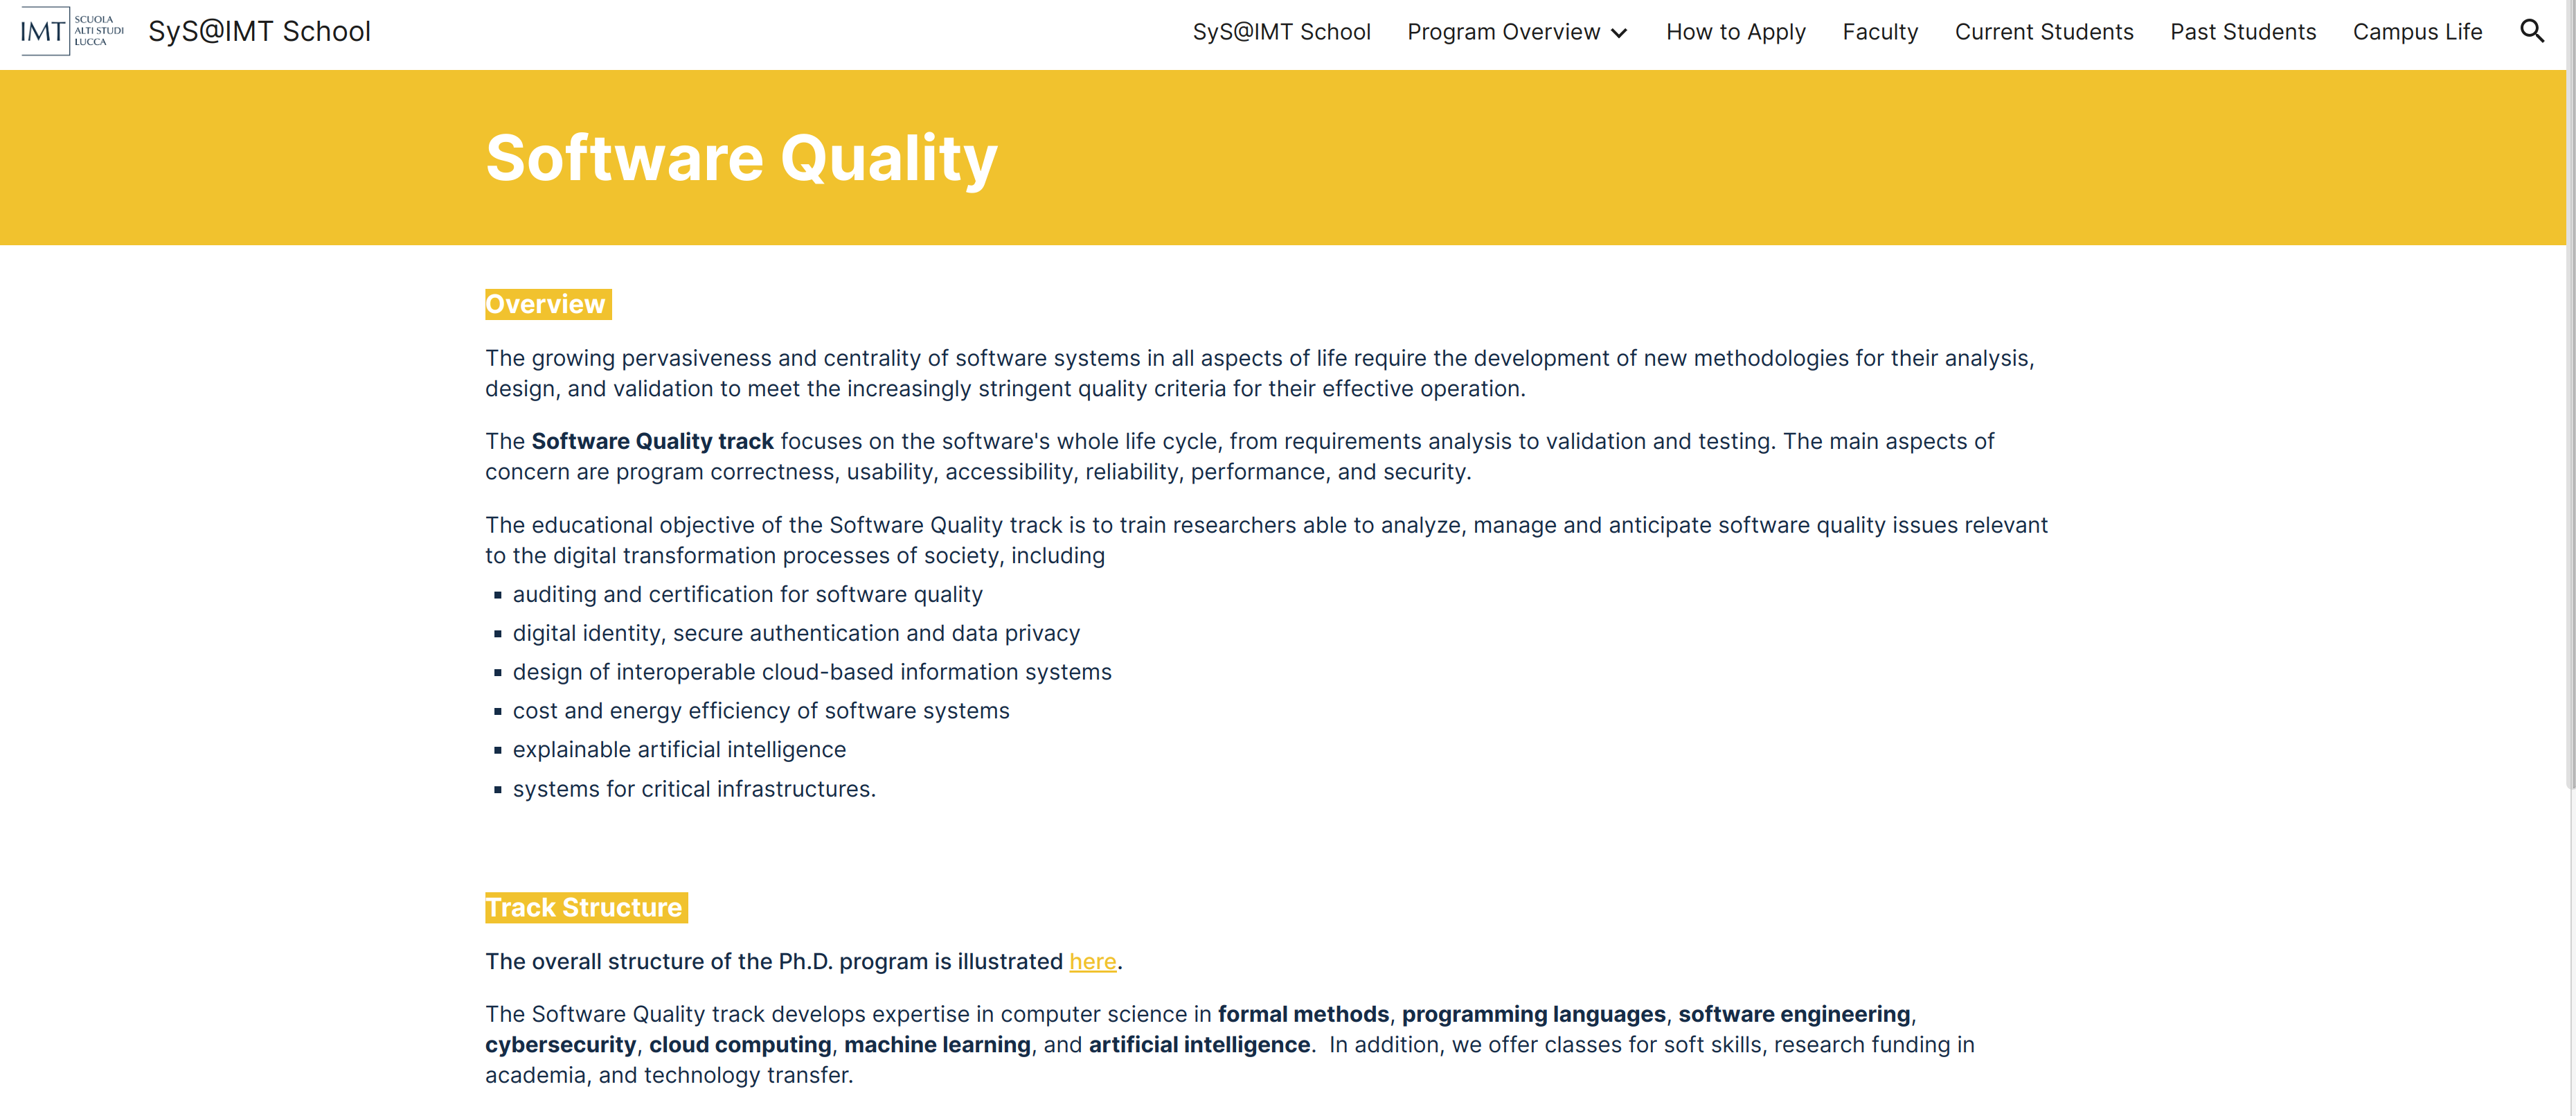



[https://sys.imtlucca.it/program-overview/software-quality-sq](https://sys.imtlucca.it/program-overview/software-quality-sq)

# Hands on Python for Data Science


### Master 2025-2026

#### Fabio Pinelli
<a href="mailto:fabio.pinelli@imtlucca.it">fabio.pinelli@imtlucca.it</a><br/>
IMT School for Advanced Studies Lucca<br/>
2025/2026<br/>
May, 16 2026

# Outline

- Pytorch
- Neural Network (fully connected)
  - Classification
  - Learning rate
  - Regression on tabular data
- CNN
- RNN



# Pytorch

## Why ```pytorch```?

1. Because I've already done something in PyTorch
2. It is widely used now in the research environment
3. It is more _pythonic_ the way it is implemented, thus the learning curve can be smoother than with other platform
  - use
  - extend
  - debug
4. Tensors are really similar to numpy arrays
5. (not in our goals) It can be used for scientific computation as well, not only for _Deep Learning_ tasks



In [86]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import pandas as pd
import seaborn as sns
import os

# to make this notebook's output stable across runs
np.random.seed(42)

#import for pytorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torch.nn.functional as F
# import torchvision
# from torchvision import transforms
from PIL import Image, ImageFile



# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "svm"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [87]:
# pytorch is available naturally on colab
# we can also use a gpu
# Go to Menu > Runtime > Change runtime.


import torch
# GPU available check
print('GPU available check {}'.format(torch.cuda.is_available()))
print(torch.rand(2,2))

GPU available check True
tensor([[0.6851, 0.9579],
        [0.3070, 0.3585]])


## Tensors

- A tensor is both a container for **numbers** and for a set of rules that define transformations between tensors producing a new tensor

- **Essentially?** A multidimensional array
- Every tensor has a rank
  - scalar --> rank 0
  - array --> rank 1
  - $n \times n$ matrix --> rank 2

```python torch.rand(2,2)``` creates a rank 2 tensor with random values by using ```python torch.rand()```



### Operations with tensors

In [88]:
# we can create a tensor from lists
x = torch.tensor([[0,0,1],[1,1,1],[0,0,0]])
print(x)

tensor([[0, 0, 1],
        [1, 1, 1],
        [0, 0, 0]])


In [89]:
(x[0][0]).item()

0

In [90]:
# we can change an element in a tensor by using standard Python indexing

x[0][0] = 5
print(x)

tensor([[5, 0, 1],
        [1, 1, 1],
        [0, 0, 0]])


We can use special creation functions to generate particular types of tensors

- ```ones()``` generates tensors filled with 1s
- ```zeros()```  generates tensors filled with 1s

In [91]:
a = torch.zeros(2,2)
b = torch.ones(2,2)
print('First tensor\n {}'.format(a))
print('Second tensor\n {}'.format(b))

First tensor
 tensor([[0., 0.],
        [0., 0.]])
Second tensor
 tensor([[1., 1.],
        [1., 1.]])


We can perform standard mathematical operations with tensors, e.g. addind two tensors together.



In [92]:
a = torch.tensor([[1,2],[2,3]])
b = torch.tensor([[1,1],[1,1]])
print('Check the sum\n {}'.format(a+b))

Check the sum
 tensor([[2, 3],
        [3, 4]])


And if you have a tensor of rank 0, you can access out the value with the ```item()``` function

In [93]:
print('Value of the 1D tensor: {}'.format(torch.rand(1).item()))

Value of the 1D tensor: 0.5410535335540771


In [94]:
torch.rand(1).shape

torch.Size([1])

Tensors can live in the **CPU** or on the **GPU** and they can be copied between devices by using the ```to()``` function:

In [95]:
cpu_tensor = torch.rand(2)
print('In which device is the tensor? {}'.format(cpu_tensor.device))

In which device is the tensor? cpu


In [96]:
gpu_tensor = cpu_tensor.to('cuda')
print('In which device is the tensor? {}'.format(gpu_tensor.device))

In which device is the tensor? cuda:0


Quite often we need to find the maximum item in a tensor, as well as the index that contains the maximum value (it may correspond to the class that the neural network has decided upon its final prediction).

```max()``` and ```argmax()``` are the needed functions, then we can use ```item()``` to get the _standard_ Python value from a 1D tensor.

In [97]:
a = torch.rand(2,2)
print(a)

print('Which is the max value? {}'.format(a.max()))
print('Which is the index of the max value: {}'.format(a.argmax()))
print('Get the values\n -max: {}\n -index: {}'.format(a.max().item(),a.argmax().item()))

tensor([[0.8062, 0.9488],
        [0.2725, 0.7836]])
Which is the max value? 0.9488164186477661
Which is the index of the max value: 1
Get the values
 -max: 0.9488164186477661
 -index: 1


In [98]:
type(a.max())

torch.Tensor

Sometimes we need to change the type of a tensor

In [99]:
long_tensor = torch.tensor([[0,0,1],[1,1,1],[0,0,0]])
print('which is the type of long tensor? {}'.format(long_tensor.type()))

which is the type of long tensor? torch.LongTensor


In [100]:
float_tensor = long_tensor.to(dtype=torch.float32)
float_tensor_2 = long_tensor.type(torch.float64) #second method to change type
print('which is the type of long tensor? {}'.format(float_tensor.type()))
print('which is the type of long tensor? {}'.format(float_tensor_2.type()))

which is the type of long tensor? torch.FloatTensor
which is the type of long tensor? torch.DoubleTensor


If you remember in ```pandas``` we could perform operations of dataframes using the parameter ```in_place = True```.

We could perform something similar on tensors.

Functions can be applied _inplace_ if exists the original fuction with appended underscore '_'.

Let see an example:

In [101]:
random_tensor = torch.rand(2,2)
new_random = random_tensor.log2()
print(random_tensor)
print(new_random)

tensor([[0.6201, 0.4189],
        [0.3231, 0.1188]])
tensor([[-0.6895, -1.2553],
        [-1.6300, -3.0731]])


In [102]:
print(random_tensor.log2_())

tensor([[-0.6895, -1.2553],
        [-1.6300, -3.0731]])


Some nice manipulation that can be done with tensors
- reshape / view
- column permutation
- slice a tensor

Let's try with a simple random tensor, and with the ```MINST``` dataset that is represented in numpy arrays of 784 elements

In [103]:
'''
reshape() function. It is really similar to numpy reshape function. There are a
lot of similarities between tensors and numpy operations/functions
'''

flat_tensor = torch.rand(784)
reshaped_tensor = flat_tensor.reshape(1,28,28) #1 is the number of channels
print('Flat tensor shape {}'.format(flat_tensor.shape))
print('Flat tensor shape {}'.format(reshaped_tensor.shape))

'''
view() function. Same behaviour of reshape, the main difference is that the view
changes if the original one is changed
'''
flat_tensor = torch.rand(784)
reshaped_tensor = flat_tensor.view(1,28,28) #1 is the number of channels
print('Flat tensor shape {}'.format(flat_tensor.shape))
print('Flat tensor shape {}'.format(reshaped_tensor.shape))

'''
The reshaped tensor can't have a number of elements different than the original one
'''
flat_tensor = torch.rand(784)
reshaped_tensor = flat_tensor.view(3,28,28)



Flat tensor shape torch.Size([784])
Flat tensor shape torch.Size([1, 28, 28])
Flat tensor shape torch.Size([784])
Flat tensor shape torch.Size([1, 28, 28])


RuntimeError: shape '[3, 28, 28]' is invalid for input of size 784

In [142]:
import numpy as np

In [143]:

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

X = mnist["data"]
y = mnist["target"].astype(np.uint8)

X_train = X[:50000]
y_train = y[:50000]

X_val = X[50000:60000]
y_val = y[50000:60000]

X_test = X[60000:]
y_test = y[60000:]

In [144]:
X[0].shape

(784,)

In [145]:
print('shape of x train: {}'.format(X_train.shape))

shape of x train: (50000, 784)


In [146]:
print(type(X_train))

<class 'numpy.ndarray'>


In [147]:
'''
Let's create a tensor from the numpy arrays
'''
x_train_tensor, x_val_tensor, x_test_tensor = map(torch.FloatTensor, (X_train, X_val, X_test))
y_train_tensor, y_val_tensor, y_test_tensor = map(torch.LongTensor, (y_train, y_val, y_test))

# y_train_tensor = y_train_tensor.type(torch.LongTensor)
# y_test_tensor = y_test_tensor.type(torch.LongTensor)

In [148]:
print(x_train_tensor.shape,x_train_tensor.size())
x_train_tensor_reshaped = x_train_tensor.reshape([-1,28,28])

print(x_train_tensor_reshaped.size())


torch.Size([50000, 784]) torch.Size([50000, 784])
torch.Size([50000, 28, 28])


In [149]:
y_train[0]

np.uint8(5)

In [150]:
x_train_tensor_reshaped[0]

tensor([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.],
        [  0.,   0.,

Dimensions permutations. The order of the "columns" is not the one useful for our tasks so we need to change the order.
For instance, images are stored as ```[height, width, channel]``` tensors, but PyTorch prefers to deal with these in a ```[channel, height, width ] order```

```
permute()
```

In [151]:
hwc_tensor = torch.rand(643,232,9)
chw_tensor = hwc_tensor.permute(2,0,1)
print('Shape of hwc tensor {}',hwc_tensor.shape)
print('Shape of chw tensor {}',chw_tensor.shape)

Shape of hwc tensor {} torch.Size([643, 232, 9])
Shape of chw tensor {} torch.Size([9, 643, 232])


In [152]:
import matplotlib.pyplot as plt

the shape is torch.Size([50000, 28, 28])
the shape of the cropped tensor is torch.Size([50000, 28, 28])


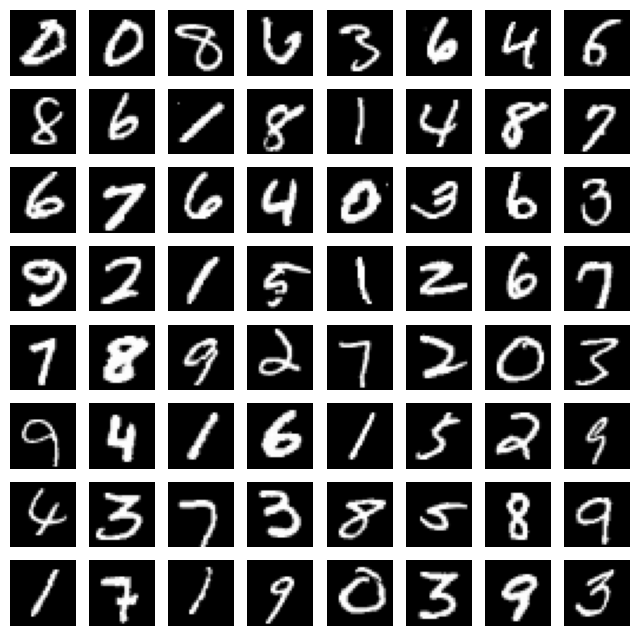

In [153]:
'''
Take the ten first lines for all the images
'''

print('the shape is {}'.format(x_train_tensor_reshaped.size()))

selected_part = x_train_tensor_reshaped[:,:,:]

print('the shape of the cropped tensor is {}'.format(selected_part.size()))

fig, axes = plt.subplots(8,8,figsize=(8,8))
for i in range(8):
    for j in range(8):
        num_index = np.random.randint(len(selected_part))
        axes[i,j].imshow(selected_part[num_index].numpy(), cmap="gray")
        axes[i,j].axis("off")
plt.show()

Numpy iteroperability:
- From ```Tensor``` to ```numpy.array```
- From ```numpy.array``` to ```Tensor```

In [154]:
points = torch.zeros(3,4)
points_np = points.numpy()

print('Type points: {}'.format(type(points)))
print('Type points_np: {}'.format(type(points_np)))

new_points = torch.from_numpy(points_np)
print('Type new_points: {}'.format(type(new_points)))


Type points: <class 'torch.Tensor'>
Type points_np: <class 'numpy.ndarray'>
Type new_points: <class 'torch.Tensor'>


# Our first Neural Network in this class :-)

- prepare the data for pytorch ```Dataset``` and ```DataLoader```
- create the network, loss, optimizer
- training


PyTorch has developed standard conventions of interacting with data that make it fairly consistent to work with, whether you are working with images, text, or audio


```Dataset``` and ```DataLoader``` are two classes used to create the data in the format needed for PyTorch.

- ```Dataset``` is a python class that allows us to get at the data we are supplying to the neural network
- ```DataLoader``` is what feeds data from the dataset into the network

Every dataset, no matter whether it includes images, audio, text, etc, can interact with PyTorch if it satisfies this abstract Python class:

```python
class Dataset(object):
  def __getitem__(self,index):
    raise NotImplementedError
  def __len__(self):
    raise NotImplementedError
```

We have to implement a method that returns the size of our dataset (```len```), and implement a method that can retrieve an item from our dataset in a (*label,tensor*) pair.

The dataset is called, then by the data loader and it pushes data into the the network.

It is possible to use the class ```TensorDataset```

There are also some package that help us on do it, for instance:
```torchvision``` with ImageFolder, ```torchtext```.

[torchvision](https://pytorch.org/vision/stable/index.html)

[torchtext](https://pytorch.org/text/stable/index.html)




## Classification

In [155]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

batch_size = 32
train_ds = TensorDataset(x_train_tensor, y_train_tensor)
train_dl = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True)

val_ds = TensorDataset(x_val_tensor, y_val_tensor)
val_dl = DataLoader(
    val_ds, batch_size=batch_size, shuffle=True)


test_ds = TensorDataset(x_test_tensor, y_test_tensor)
test_dl = DataLoader(test_ds, batch_size=batch_size)


Let's try to define our `Dataset`

In [156]:
from torch.utils.data import Dataset, DataLoader
class imageDataset(Dataset):

    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data

    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]

    def __len__ (self):
        return len(self.X_data)


In [157]:
train_ds = imageDataset(x_train_tensor, y_train_tensor)
train_dl = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True)


### The network


The definition of a network uses the ```nn.Module``` of pytorch.

- ```Linear``` defines the structure of each layer
- ```forward``` defines how the data should flow across the different layers of the network
- ```relu``` is the activation function

For each layer we define the size of the input and the output.
For instance, the first layer takes in input the same shape of the MINST images. Then, it passes the dato to a 200 neurons.

The latest layer returns an output **equal** to the **number of classes**.

To understand which is the predicted class we need to take the ```argmax()``` of the output, such as the index of max score assigned to each instance by the network.

In [158]:
class SimpleNet(nn.Module):

    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 50)
        self.fc3 = nn.Linear(50,10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [159]:
'''
create an instance of the network
'''
simplenet = SimpleNet()

In [160]:
'''
Random weight inizialization
'''

simplenet.state_dict()

OrderedDict([('fc1.weight',
              tensor([[ 0.0125,  0.0223, -0.0337,  ...,  0.0144,  0.0093, -0.0138],
                      [-0.0077, -0.0032,  0.0065,  ...,  0.0098,  0.0275, -0.0079],
                      [-0.0150,  0.0273,  0.0336,  ..., -0.0090,  0.0177,  0.0102],
                      ...,
                      [ 0.0228, -0.0060,  0.0111,  ..., -0.0220,  0.0172,  0.0106],
                      [-0.0324, -0.0230, -0.0099,  ..., -0.0032,  0.0281,  0.0151],
                      [-0.0204, -0.0301, -0.0107,  ..., -0.0277,  0.0114, -0.0147]])),
             ('fc1.bias',
              tensor([ 4.7893e-03, -2.8827e-02, -3.5690e-02, -2.3224e-02, -1.8838e-02,
                      -1.4402e-03, -2.7911e-02, -2.5115e-02, -1.6298e-02, -2.9607e-03,
                       1.9838e-02, -1.2105e-03, -6.9121e-03,  2.1296e-02,  3.1040e-02,
                      -3.2581e-02,  6.3177e-03,  1.0628e-02, -2.6623e-02, -2.5840e-02,
                       2.3745e-02, -2.0552e-02, -8.5668e-03,  3.

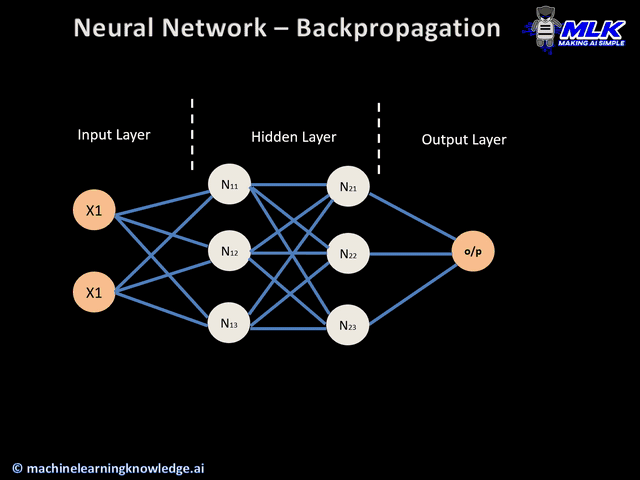

In [161]:
'''
Definition of an optimizer, in this case we select the Adam optimizer
Another possible optimizer is the SGD that is possibile to select from
the same class optim
'''
optimizer = optim.Adam(simplenet.parameters(), lr=0.001)
# optimizer_regr = optim.SGD(simplenet.parameters(),lr=0.0001)

In [162]:
simplenet.parameters()

<generator object Module.parameters at 0x7a0807ac33e0>

In [163]:
'''
And then, we need a definition of the loss.
Also in this case, we can select one of those made available by pytorch
For regression, for instance we could select the MSELoss
'''
loss = nn.CrossEntropyLoss()
loss_regression = nn.MSELoss()

In [164]:
'''
Let's put everything together.
The network, the optimizer and the loss inside a training loop, using the DataLoader
objects that we have already created.
'''

'''
Note: model.train() --> the model is set on training mode, where the weights and biases
are adjusted using the training instance passed in batches.
'''


'''
Note: model.eval() --> when we evaluate the model on the validation set.
'''

'''
This function with some refinements can be used for any model, the training process
is really similar, it might change few details
'''

def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="cpu"):
    model.to(device)
    for epoch in range(1, epochs+1):
        training_loss = 0.0
        valid_loss = 0.0
        model.train() #train status for the mode
        for batch in train_loader:
            optimizer.zero_grad() # clear gradients for next train
            inputs, targets = batch
            # print(f'input shape: {inputs.shape}')
            # print(f'target shape: {targets.shape}')
            inputs = inputs.to(device)
            targets = targets.to(device)
            output = model(inputs)
            loss = loss_fn(output, targets)
            loss.backward() # backpropagation, compute gradients
            optimizer.step() # apply gradients
            training_loss += loss.data.item() * inputs.size(0)
            # print(training_loss,loss.data.item(),inputs.size(0))
        training_loss /= len(train_loader.dataset)

        with torch.no_grad(): # we are not updating the model
          model.eval() #the status of the model is in eval
          num_correct = 0
          num_examples = 0
          for batch in val_loader:
              inputs, targets = batch
              inputs = inputs.to(device)
              output = model(inputs)
              targets = targets.to(device)
              loss = loss_fn(output,targets)
              valid_loss += loss.data.item() * inputs.size(0)
              correct = torch.eq(torch.max(F.softmax(output, dim=1), dim=1)[1], targets)
              num_correct += torch.sum(correct).item()
              num_examples += correct.shape[0]
          valid_loss /= len(val_loader.dataset)

        print('Epoch: {}, Training Loss: {:.4f}, Validation Loss: {:.4f}, accuracy = {:.4f}'.format(epoch, training_loss,
        valid_loss, num_correct / num_examples))

1. In each epoch:
  
  a. we take a batch $b$ from our training set
  
  b. we pass $b$ to our model and we compute the loss from the $output$
  
  c. to compute the gradients, we call ```backward()```
  
  d. the ```optimizer.step()``` method uses those gradients afterward to perform the adjustments of the weights

```zero_grad()``` it is used to make sure that gradients are not influeced by previous batches.


- Softmax Activation: F.softmax(output, dim=1) F.softmax(output, dim=1): Applies the softmax function to the output tensor along the specified dimension dim=1. The softmax function converts the raw output logits into probabilities that sum to 1 for each sample in the batch.

- output: This is typically the raw output logits from the last layer of a neural network.
- dim=1: Specifies that the softmax function should be applied along the second dimension of the output tensor (which is usually the class dimension in a batch of outputs).
- Maximum Value and Index: torch.max(..., dim=1) torch.max(..., dim=1): Finds the maximum value and its corresponding index along the specified dimension dim=1.
The result is a tuple where the first element is the maximum values and the second element is the indices of those maximum values.
Extracting Indices: [1]

- The [1] at the end extracts the indices of the maximum values. These indices correspond to the predicted class labels.


In [165]:
'''
How to move the model to cuda (if available)
'''

if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

simplenet.to(device)


SimpleNet(
  (fc1): Linear(in_features=784, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=10, bias=True)
)

In [166]:
train(simplenet, optimizer,torch.nn.CrossEntropyLoss(), train_dl,val_dl, epochs=5)

Epoch: 1, Training Loss: 0.3194, Validation Loss: 0.2066, accuracy = 0.9403
Epoch: 2, Training Loss: 0.1573, Validation Loss: 0.1417, accuracy = 0.9596
Epoch: 3, Training Loss: 0.1277, Validation Loss: 0.1608, accuracy = 0.9561
Epoch: 4, Training Loss: 0.1138, Validation Loss: 0.1329, accuracy = 0.9665
Epoch: 5, Training Loss: 0.0993, Validation Loss: 0.1527, accuracy = 0.9648


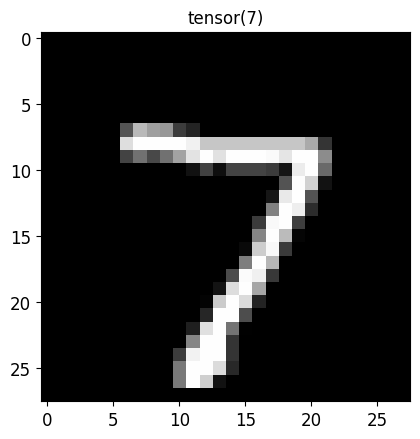

All the scores: tensor([-16.6883, -14.2882,  -6.8755,  -9.0447, -14.1902, -12.4007, -26.5339,
          1.7674, -10.7202,  -8.2094])
The max score: 1.7674154043197632
The index of the max score: 7


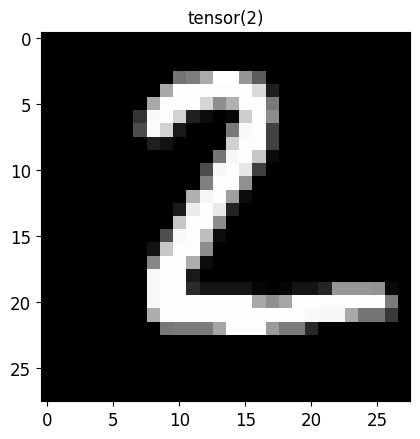

All the scores: tensor([-10.2346,  -6.9344,  12.1355,  -2.3924, -51.7369, -27.0983, -23.2926,
        -17.4966, -15.3084, -36.7343])
The max score: 12.13548469543457
The index of the max score: 2


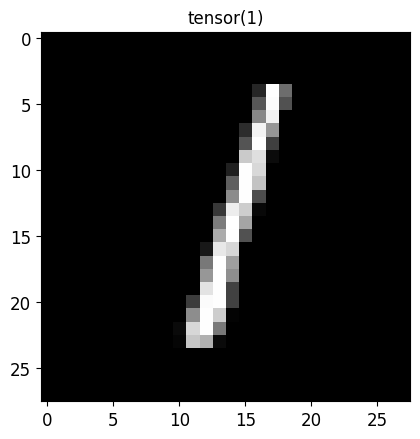

All the scores: tensor([-4.6654, 21.4032,  7.4565,  7.6113,  5.1228,  6.8688, 12.8440,  8.9934,
        14.1468,  8.9448])
The max score: 21.40317726135254
The index of the max score: 1


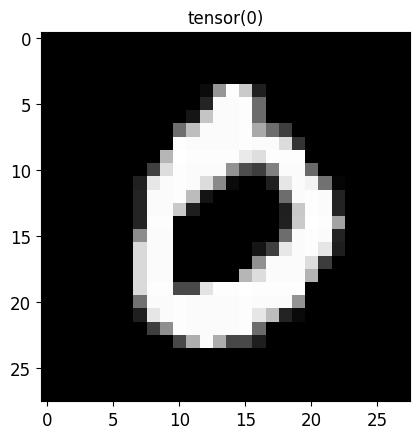

All the scores: tensor([ 14.2740, -14.8272,   0.5953,  -4.7751, -10.6015,  -2.6980,  -5.6115,
         -1.0224,  -7.9573,  -5.7646])
The max score: 14.274031639099121
The index of the max score: 0


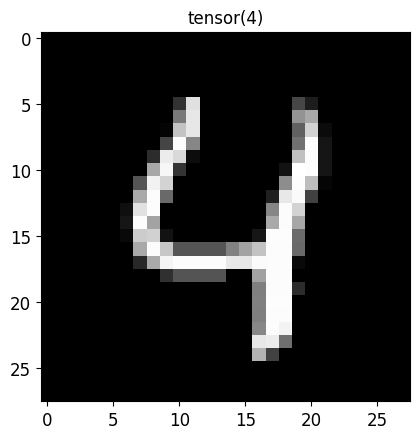

All the scores: tensor([-2.8212,  8.1817,  2.7835, -4.4999, 24.0323, -2.4138, -4.1703,  7.1369,
         5.7531,  9.0923])
The max score: 24.032299041748047
The index of the max score: 4


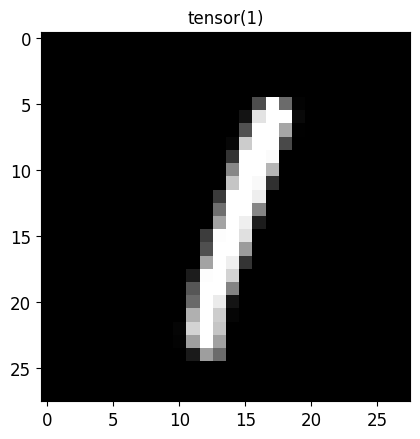

All the scores: tensor([-4.8345, 31.7040, 10.9258, 10.4145,  8.6263,  9.5637, 16.9920, 14.4307,
        19.8764, 14.4232])
The max score: 31.703989028930664
The index of the max score: 1


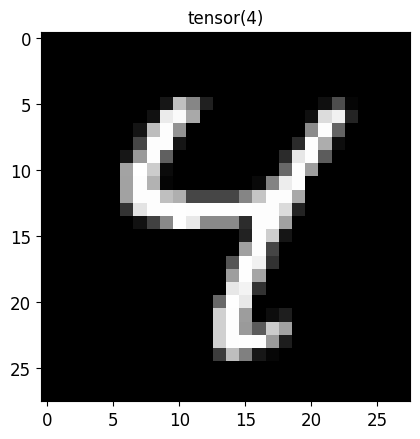

All the scores: tensor([ 0.0473,  6.6331,  6.4806, -4.0687, 20.7917, -1.8010,  0.1921,  3.6380,
         9.1422,  5.5598])
The max score: 20.791667938232422
The index of the max score: 4


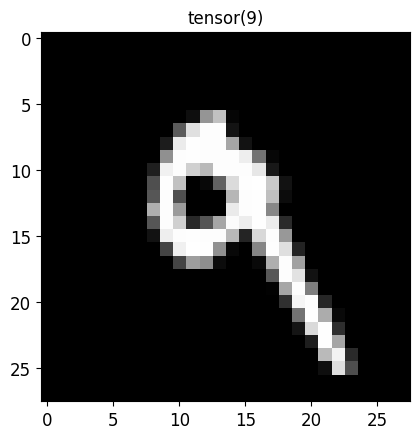

All the scores: tensor([ 1.1025,  2.6349, -1.7486,  3.7786,  5.7056,  3.2543, -3.4415,  4.9178,
         4.2324,  9.8213])
The max score: 9.821295738220215
The index of the max score: 9


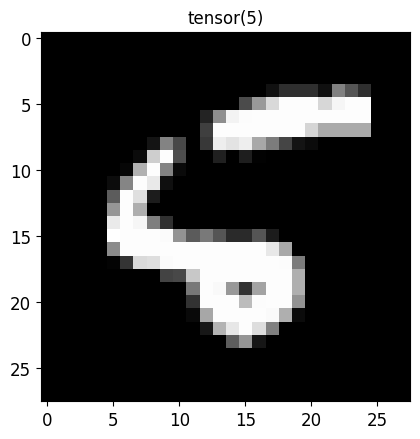

All the scores: tensor([  4.6595,   0.7739,   3.0614,   5.3417,   5.6675,  11.5125,  14.5597,
        -13.5632,   5.7599,   8.8404])
The max score: 14.559673309326172
The index of the max score: 6


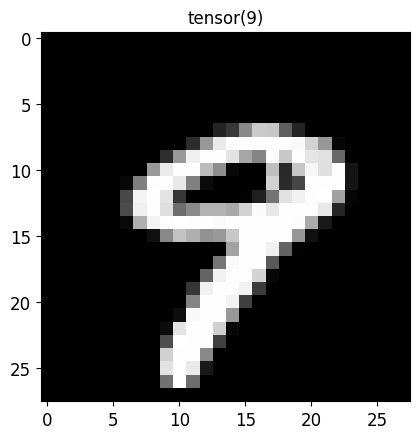

All the scores: tensor([-0.4343,  2.5977, -2.6816,  3.3102, 10.1297,  2.2060, -9.4770,  8.5002,
         6.0970, 14.4508])
The max score: 14.450803756713867
The index of the max score: 9


In [167]:
with torch.no_grad():
  simplenet.eval() # we move to eval state, since we don't need to update the weights and biases
  for i in range(10):
    plt.imshow(x_test_tensor[i].reshape((28,28)), cmap="gray")
    plt.title(y_test_tensor[i])
    plt.show()
    print("All the scores: {}".format(simplenet(x_test_tensor[i].float())))
    print("The max score: {}".format(simplenet(x_test_tensor[i].float()).max()))
    print("The index of the max score: {}".format(simplenet(x_test_tensor[i].float()).argmax()))

## Methods to find the best **Learning Rate**
- gridsearch: use different learning rate values, and verify which is the best parameters configuration w.r.t. a certain error measure
- Over the course of an epoch start out with a small learning rate and increase it to higher values over each batch. At the end of the epoch the learning rate will be high. We compute the ```loss``` for each rate.

Then find in a plot (learning_rate, loss) the learning rate that gives the greatest decline.

In [168]:
def find_lr(model, loss_fn, optimizer, train_loader,init_value = 1e-8, final_value=1, device="cpu"):
    number_in_epoch = len(train_loader) - 1
    update_step = (final_value / init_value) ** (1 / number_in_epoch)
    lr = init_value
    optimizer.param_groups[0]["lr"] = lr
    training_loss = 0.0
    best_loss = 0.0
    batch_num = 0
    losses = []
    log_lrs = []
    model.train()
    for data in train_loader:
      # print('Batch number: {}'.format(batch_num))
      batch_num += 1
      inputs, targets = data
      inputs = inputs.to(device)
      targets = targets.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = loss_fn(outputs, targets)
      # print(loss)
      # Crash out if loss explodes

      if batch_num > 1 and loss > 10 * best_loss:
        print('Exploded current loss: {} best_loss: {}'.format(loss,best_loss))
        return log_lrs, losses

      # Record the best loss

      if loss < best_loss or batch_num == 1:
          best_loss = loss

      # Store the values
      losses.append(loss.item())
      log_lrs.append((lr))

      # Do the backward pass and optimize

      loss.backward()
      optimizer.step()

        # Update the lr for the next step and store

      lr *= update_step
      optimizer.param_groups[0]["lr"] = lr

    print(len(log_lrs),len(losses))
    if len(log_lrs) > 20:
      print(len(log_lrs),len(losses))
      return log_lrs[10:-5], losses[10:-5]
    else:
      return log_lrs, losses


In [169]:
#load the data again just to be sure what we are using
batch_size = 128
train_ds = TensorDataset(x_train_tensor, y_train_tensor)
train_dl = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True)

simplenet = SimpleNet()
optimizer = optim.Adam(simplenet.parameters(), lr=0.001)
(lrs, losses) = find_lr(simplenet, torch.nn.CrossEntropyLoss(), optimizer, train_dl,device='cpu')


Exploded current loss: 5.752065658569336 best_loss: 0.3148636817932129


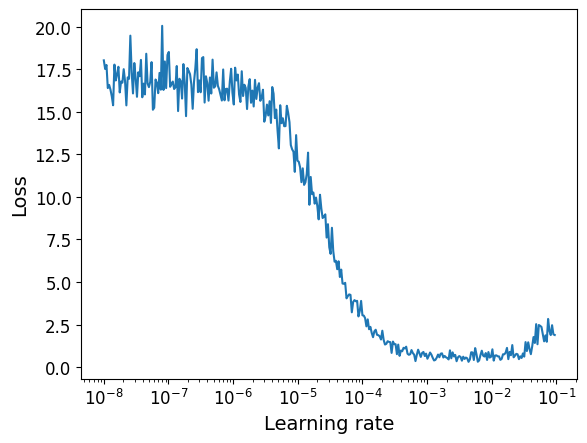

In [170]:
plt.plot(lrs, losses,)

plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.show()

## Regression
Let's try now with a regression problem

we will use the wine quality data and try to regress on the quality

In [171]:
path_github = 'https://raw.githubusercontent.com/fpinell/hands_on_python_for_ds/main/data/winequality-white.csv'
df = pd.read_csv(path_github,sep=';')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


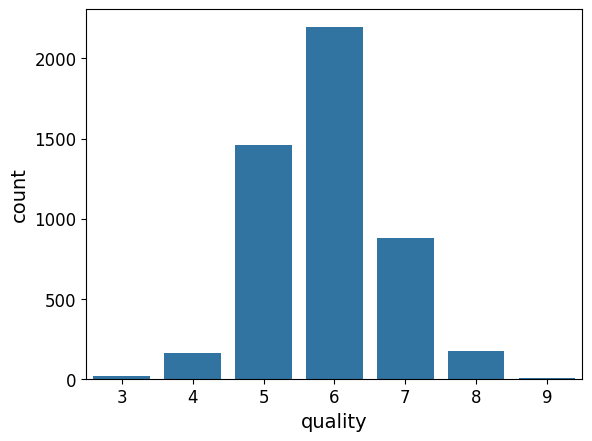

In [173]:
import seaborn as sns

sns.countplot(x = 'quality', data=df)

X = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

In [174]:
from sklearn.model_selection import train_test_split

# Train - Test
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=69)
# Split train into train-val
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.1, random_state=21)


In [175]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler() # scaling the data
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
X_train, y_train = np.array(X_train), np.array(y_train)
X_val, y_val = np.array(X_val), np.array(y_val)
X_test, y_test = np.array(X_test), np.array(y_test)

In [176]:
x_train = np.array([[1,2,3],[2,3,4],[1.3,1.3,3.4]])
x_test = np.array([[1,2,3],[2,5,4]])

In [177]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(x_train)

In [178]:
X_train


array([[0.        , 0.41176471, 0.        ],
       [1.        , 1.        , 1.        ],
       [0.3       , 0.        , 0.4       ]])

In [179]:
scaler.data_min_

array([1. , 1.3, 3. ])

In [180]:
y_train, y_test, y_val = y_train.astype(float), y_test.astype(float), y_val.astype(float)


In [181]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
class RegressionDataset(Dataset):

    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data

    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]

    def __len__ (self):
        return len(self.X_data)


In [182]:
train_dataset = RegressionDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float())
val_dataset = RegressionDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float())
test_dataset = RegressionDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float())

In [183]:
print("The type of train_dataset is? {}".format(type(train_dataset)))

The type of train_dataset is? <class '__main__.RegressionDataset'>


In [184]:
EPOCHS = 150
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_FEATURES = X.shape[1]

In [185]:
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=32)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [186]:

print("The type of train_dataset is? {}".format(type(train_loader)))

The type of train_dataset is? <class 'torch.utils.data.dataloader.DataLoader'>


In [187]:
class MultipleRegression(nn.Module):
    def __init__(self, num_features):
        super(MultipleRegression, self).__init__()

        self.layer_1 = nn.Linear(num_features, 16)
        self.layer_2 = nn.Linear(16, 32)
        self.layer_3 = nn.Linear(32, 16)
        self.layer_out = nn.Linear(16, 1)

        self.relu = nn.ReLU()

    def forward(self, inputs):
        x = self.relu(self.layer_1(inputs))
        x = self.relu(self.layer_2(x))
        x = self.relu(self.layer_3(x))
        x = self.layer_out(x)
        return (x)

    def predict(self, test_inputs):
        x = self.relu(self.layer_1(test_inputs))
        x = self.relu(self.layer_2(x))
        x = self.relu(self.layer_3(x))
        x = self.layer_out(x)
        return (x)

In [188]:
model = MultipleRegression(NUM_FEATURES)
# model.to(device)
print(model)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


MultipleRegression(
  (layer_1): Linear(in_features=11, out_features=16, bias=True)
  (layer_2): Linear(in_features=16, out_features=32, bias=True)
  (layer_3): Linear(in_features=32, out_features=16, bias=True)
  (layer_out): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)


In [189]:
loss_stats = {
    'train': [],
    "val": []
}

In [190]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [191]:
model.to(device)
print("Begin training.")
for e in range(1, EPOCHS+1):

    # TRAINING
    train_epoch_loss = 0
    model.train()
    for X_train_batch, y_train_batch in train_loader:
        X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)
        optimizer.zero_grad()

        y_train_pred = model(X_train_batch)

        train_loss = criterion(y_train_pred, y_train_batch.reshape(-1,1))

        train_loss.backward()
        optimizer.step()

        train_epoch_loss += train_loss.item()
    # VALIDATION
    with torch.no_grad():

        val_epoch_loss = 0

        model.eval()
        for X_val_batch, y_val_batch in val_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)

            y_val_pred = model(X_val_batch)

            val_loss = criterion(y_val_pred, y_val_batch.unsqueeze(1))

            val_epoch_loss += val_loss.item()
        loss_stats['train'].append(train_epoch_loss/len(train_loader))
        loss_stats['val'].append(val_epoch_loss/len(val_loader))

    print(f'Epoch {e+0:03}: | Train Loss: {train_epoch_loss/len(train_loader):.5f} | Val Loss: {val_epoch_loss/len(val_loader):.5f}')


Begin training.


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x3 and 11x16)

In [ ]:
train_val_loss_df = pd.DataFrame.from_dict(loss_stats).reset_index().melt(id_vars=['index']).rename(columns={"index":"epochs"})
plt.figure(figsize=(10,6))
sns.lineplot(data=train_val_loss_df, x = "epochs", y="value", hue="variable").set_title('Train-Val Loss/Epoch')

In [ ]:
y_pred_list = []
with torch.no_grad():
    model.eval()
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        y_test_pred = model(X_batch)
        y_pred_list.append(y_test_pred.cpu().numpy())
y_pred_list = [a.squeeze().tolist() for a in y_pred_list]

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred_list)
r_square = r2_score(y_test, y_pred_list)
print("Mean Squared Error :",mse)
print("R^2 :",r_square)

### Gridsearch


let pytorch speak the same scikit language. Wrap the models to interact with the *GridSearchCV* object


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target


In [ ]:
class PyTorchClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim, output_dim, hidden_dim=10, epochs=10,
                 batch_size=32, learning_rate=0.01):
        # ONLY store params. No work here.
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate

    def _build_model(self):
        return nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.output_dim),
        )

    def fit(self, X, y):
        # Build everything here, using the current param values.
        self.model_ = self._build_model()
        self.criterion_ = nn.CrossEntropyLoss()
        self.optimizer_ = optim.SGD(self.model_.parameters(), lr=self.learning_rate)
        self.classes_ = np.unique(y)  # nice to have for ClassifierMixin

        self.model_.train()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)
        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X_tensor, y_tensor),
            batch_size=self.batch_size, shuffle=True,
        )

        for _ in range(self.epochs):
            for inputs, targets in loader:
                self.optimizer_.zero_grad()
                loss = self.criterion_(self.model_(inputs), targets)
                loss.backward()
                self.optimizer_.step()
        return self

    def predict(self, X):
        self.model_.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32)
            _, predicted = torch.max(self.model_(X_tensor), 1)
            return predicted.numpy()

In [ ]:
# Define the model as part of a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Scaling the data
    ('classifier', PyTorchClassifier(input_dim=4, output_dim=3))  # PyTorch model
])

# Define the parameter grid
param_grid = {
    'classifier__hidden_dim': [5, 10, 15],
    'classifier__epochs': [10, 20],
    'classifier__batch_size': [16, 32],
    'classifier__learning_rate': [0.001, 0.01]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(pipeline, param_grid, cv=3)



In [ ]:
# Fit the GridSearchCV object
grid_search.fit(X, y)

# Get the best parameters and score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)


# Convolutional Neural Network (CNN)

- The fully connected network can function as a universal approximator, but we don't know how long it will take to train it to become a good approximation
- In particular, for images it could be interesting to capture locality and translation invariance
  - Check the nearby pixels to recognize objects
  - It leverages the position of the pixels that is completely destroyed in a 1 dimensional array
  - tadaaa convolution: scalar product of a weight matrix (kernel) with every neighborhood in the input.


In [ ]:

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False,parser='auto')

X = mnist["data"]
y = mnist["target"].astype(np.uint8)

X_train = X[:50000]
y_train = y[:50000]

X_val = X[50000:60000]
y_val = y[50000:60000]

X_test = X[60000:]
y_test = y[60000:]

In [ ]:
'''
Let's create a tensor from the numpy arrays
'''
x_train_tensor,x_val_tensor, x_test_tensor = map(torch.FloatTensor, (X_train, X_val, X_test))
y_train_tensor,y_val_tensor, y_test_tensor = map(torch.LongTensor, (y_train, y_val, y_test))

# y_train_tensor = y_train_tensor.type(torch.LongTensor)
# y_test_tensor = y_test_tensor.type(torch.LongTensor)

In [ ]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

batch_size = 32
train_ds = TensorDataset(x_train_tensor, y_train_tensor)
train_dl = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True)

val_ds = TensorDataset(x_val_tensor, y_val_tensor)
val_dl = DataLoader(
    val_ds, batch_size=batch_size, shuffle=True)


test_ds = TensorDataset(x_test_tensor, y_test_tensor)
test_dl = DataLoader(test_ds, batch_size=batch_size)


Convolution parameters:
- ```in_channel``` is the number of input channels (1 for grey images, 3 for rgb)
- ```out_channel``` the number of output channels
- ```kernel_size``` eight and width of the kernel filter, if only one value is passed then eight = width
- ```stride``` how many steps across the input we move when we adjust the filter to a new position
- ```padding``` it can happen that we don't have enough elements in our input to do a full convolution. In these cases, the empty values are filled with the ```padding``` values

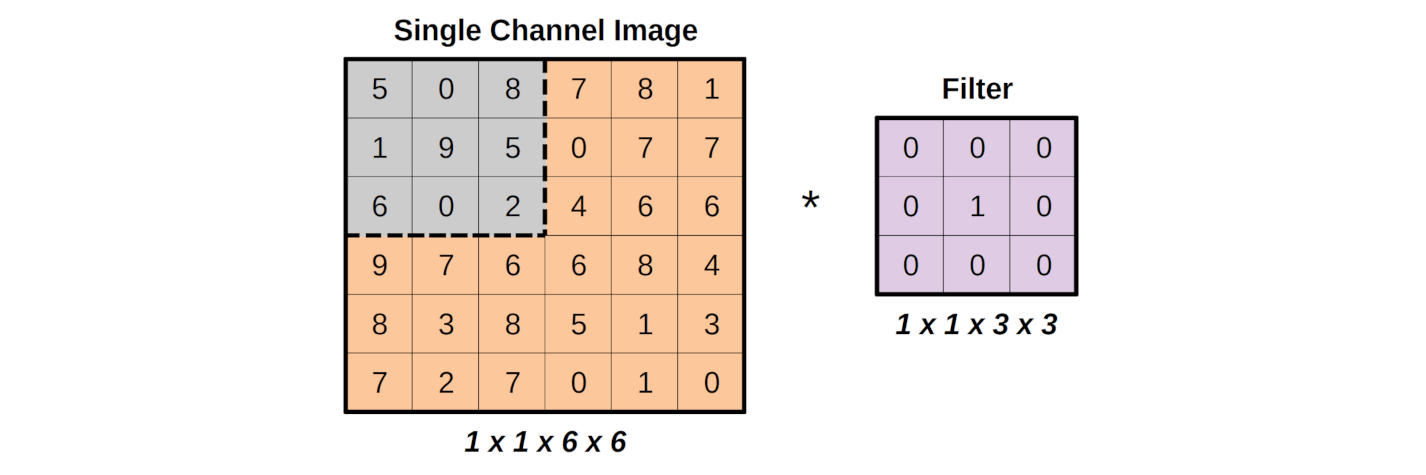

In [ ]:
single = np.array(
    [[[[5, 0, 8, 7, 8, 1],
       [1, 9, 5, 0, 7, 7],
       [6, 0, 2, 4, 6, 6],
       [9, 7, 6, 6, 8, 4],
       [8, 3, 8, 5, 1, 3],
       [7, 2, 7, 0, 1, 0]]]]
)
single.shape

In [ ]:
identity = np.array(
    [[[[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]]]]
)
identity.shape

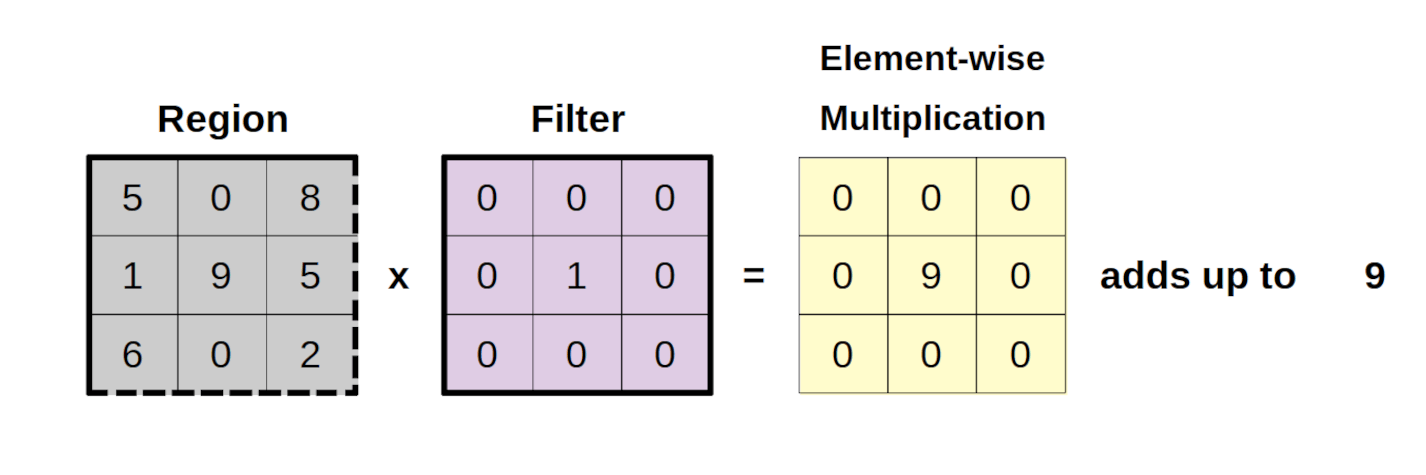

In [ ]:
region = single[:, :, 0:3, 0:3]
filtered_region = region * identity
total = filtered_region.sum()
total

In [ ]:
filtered_region

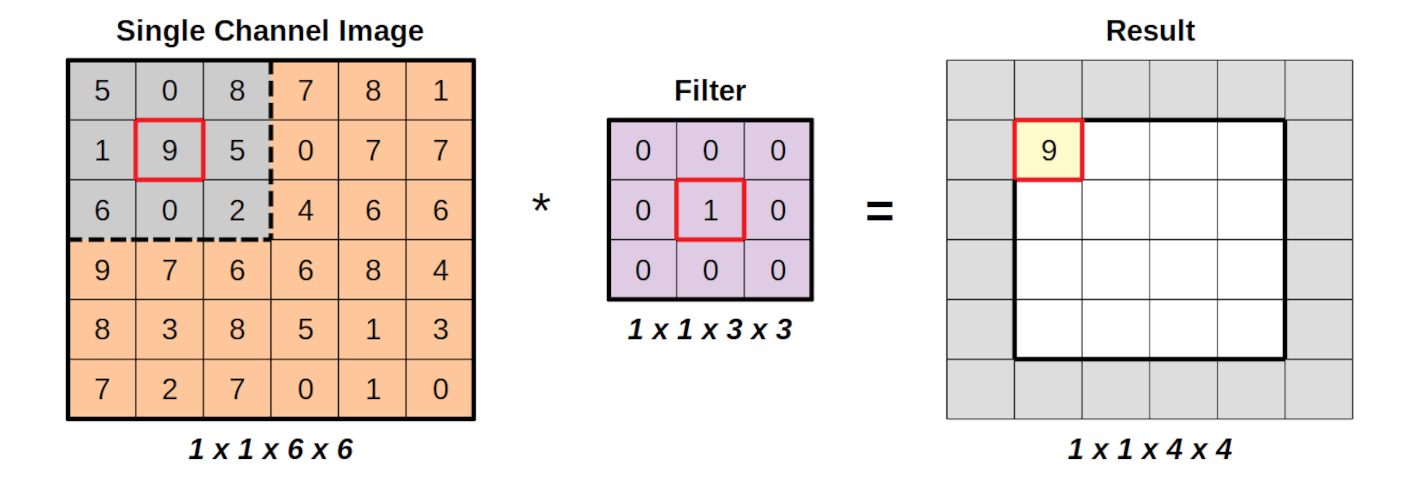

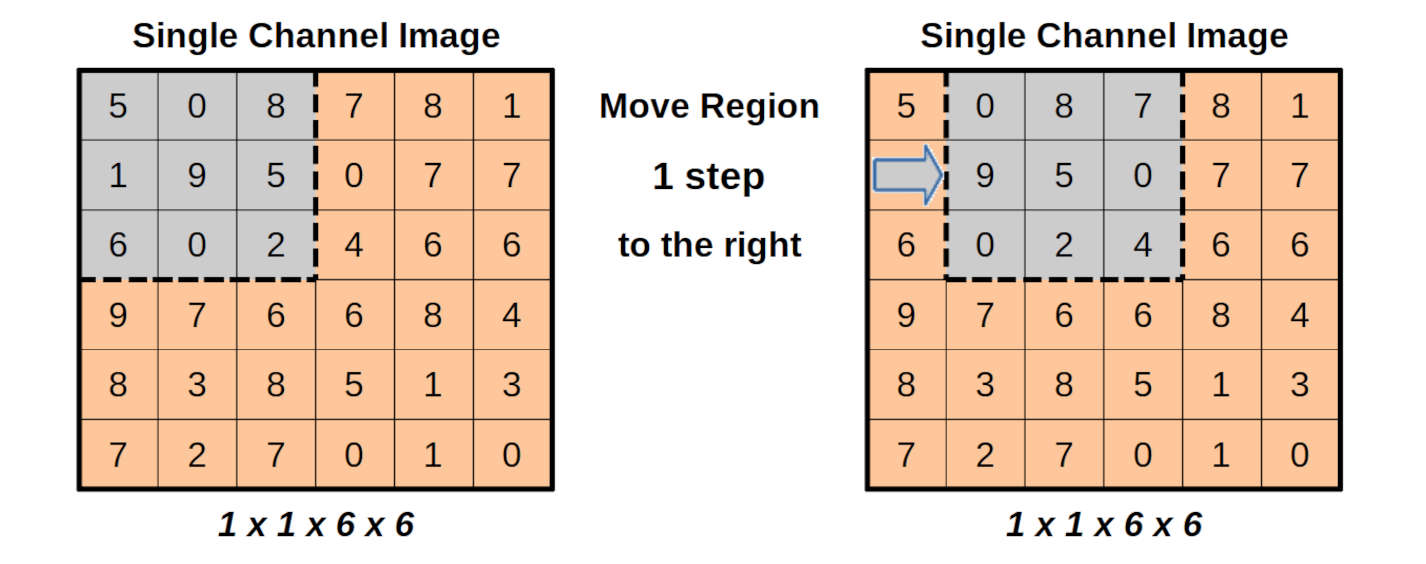

In [192]:
new_region = single[:, :, 0:3, (0+1):(3+1)]
new_filtered_region = new_region * identity
new_total = new_filtered_region.sum()
new_total

np.int64(9)

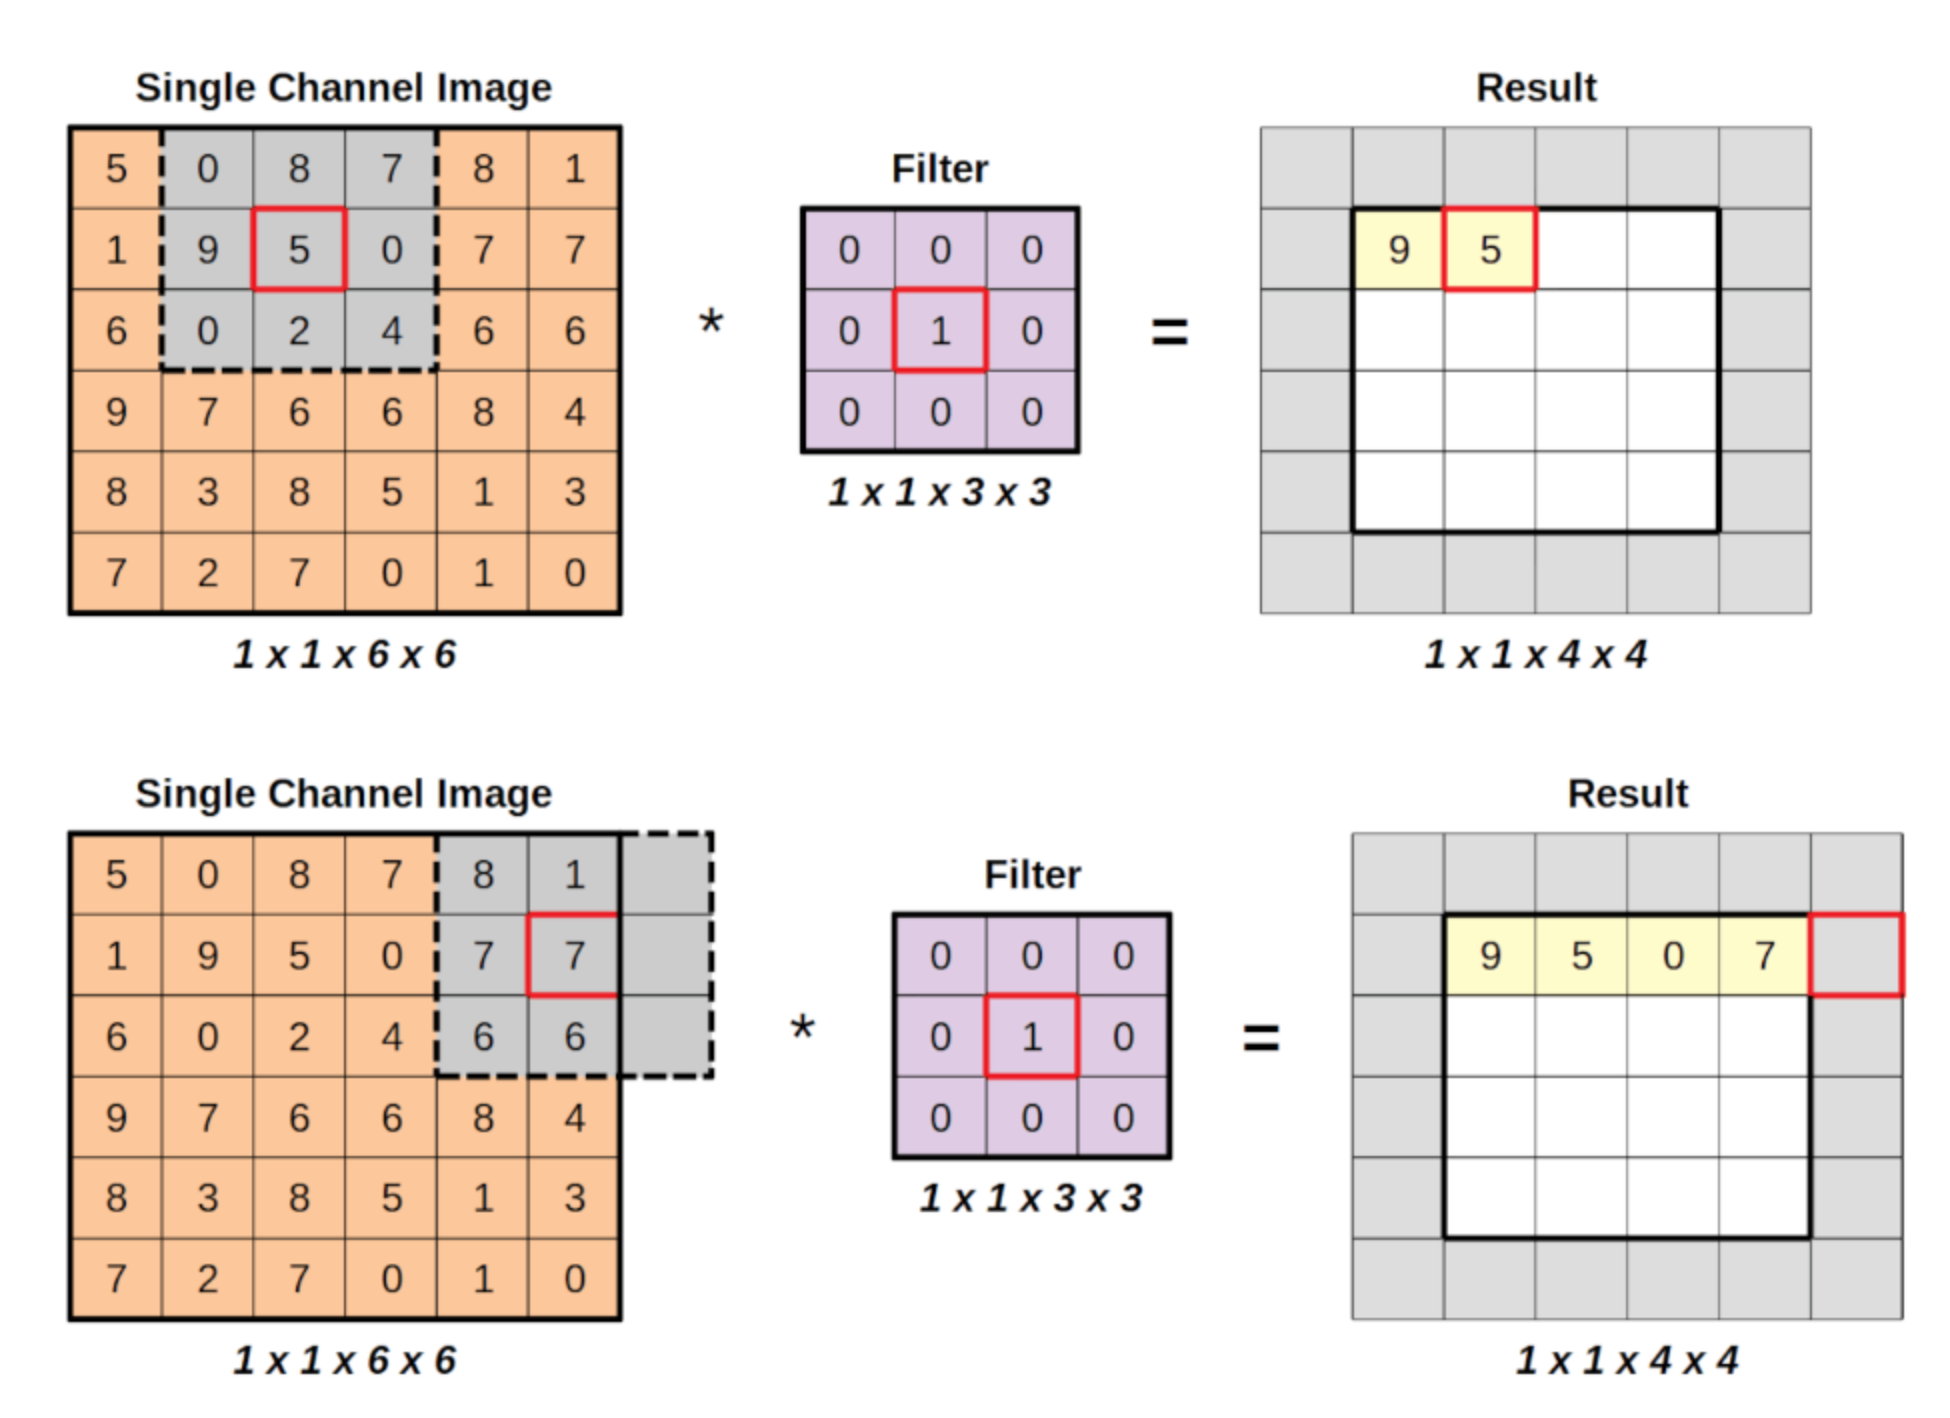

In [193]:
last_horizontal_region = single[:, :, 0:3, (0+4):(3+4)]
last_horizontal_region * identity


ValueError: operands could not be broadcast together with shapes (1,1,3,2) (1,1,3,3) 

Convolving in pytorch

In [194]:
identity

array([[[[1, 0, 0],
         [0, 1, 0],
         [0, 0, 1]]]])

In [195]:
image = torch.as_tensor(single).float()
kernel_identity = torch.as_tensor(identity).float()
convolved = F.conv2d(image, kernel_identity, stride=1)
convolved

tensor([[[[16.,  9., 14., 20.],
          [ 7., 17., 17., 10.],
          [21., 11.,  9., 15.],
          [19., 15., 12.,  7.]]]])

In [196]:
convolved.shape

torch.Size([1, 1, 4, 4])

The `nn.Conv2d` has many arguments but let's focus on the first four of them

- in_channels --> number of channels of the input image
- out_channels --> number of channels produced by the convolution
- kernel_size --> size of the convolutional filter (typically squared)
- stride --> the size of the movement of the selected region

If you can see:

#### THE KERNEL IS NOT AN ARGUMENT OF THE MODULE!
--> The kernel is **learned** by the module

#### It is possible to produce multiple channels as output
--> The module is going to learn multiple filters, each filter is going to produce different **result**.

```conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1)```

In [197]:
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1)
conv(image)

tensor([[[[-1.3110, -1.4973, -2.4105,  0.4153],
          [-4.6653, -2.1361, -5.2174, -2.8036],
          [-5.4685, -4.2492, -2.8435, -0.9402],
          [-3.2317, -0.0170, -2.1805,  1.0702]]]],
       grad_fn=<ConvolutionBackward0>)

In [198]:
conv.weight

Parameter containing:
tensor([[[[ 0.0289,  0.3191, -0.1543],
          [-0.2604,  0.1637,  0.0875],
          [-0.2417, -0.2547, -0.2569]]]], requires_grad=True)

In [199]:
'''
And with more filters to learn?
'''

conv_multiple = nn.Conv2d(in_channels=1, out_channels=2, kernel_size=3, stride=1)
conv_multiple(image).shape

torch.Size([1, 2, 4, 4])

So far we used to move one pixel at the time, meaning with a *stride* equal to 1

Let's try to see what happen if we use the `stride = 2`

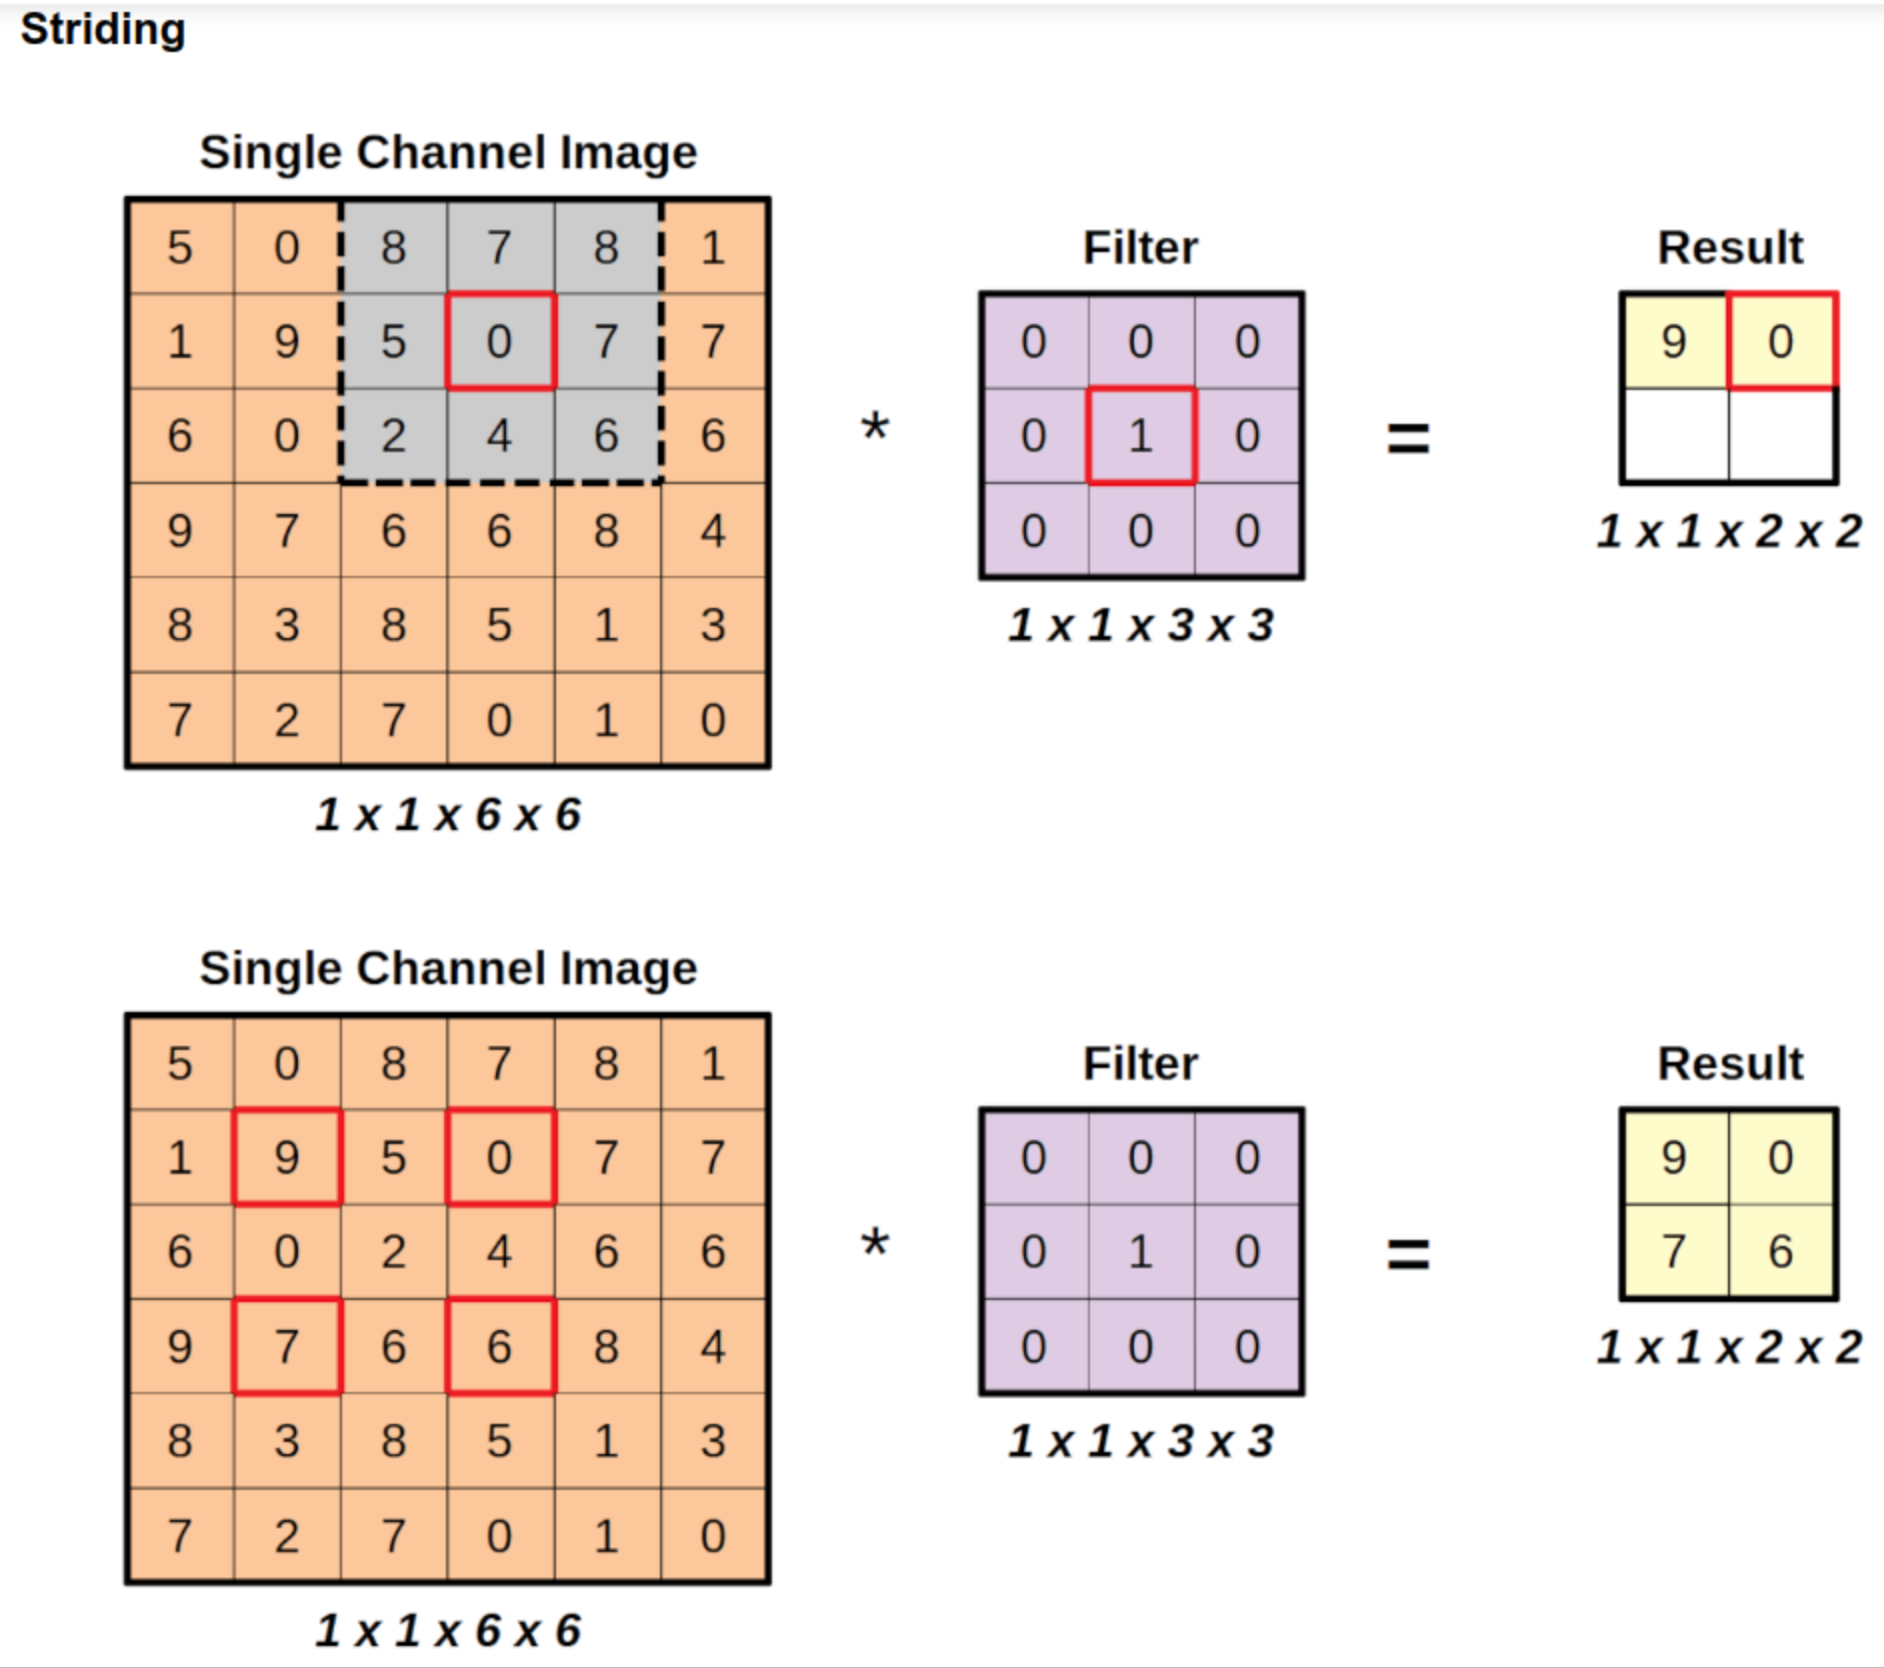

<img src="https://drive.google.com/uc?export=view&id=1YK6yyW4nHVokldiKYOztQIqRiUtyMPcf" width="50%">


In [200]:
convolved_stride2 = F.conv2d(image, kernel_identity, stride=2)
convolved_stride2

tensor([[[[16., 14.],
          [21.,  9.]]]])

In [201]:
convolved_stride2.shape

torch.Size([1, 1, 2, 2])

## Padding

We need to add something to the image in order to sustain the attacks on its size

Full of 0's around the image.

The grey region is now centered on the top left corner of the image.


<img src="https://drive.google.com/uc?export=view&id=1dvDE3v2hNNpnQC3dRmwahOOOfE5YMxhO" width="100%">

In [202]:
constant_padder = nn.ConstantPad2d(padding=1, value=0)
constant_padder(image)

tensor([[[[0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 5., 0., 8., 7., 8., 1., 0.],
          [0., 1., 9., 5., 0., 7., 7., 0.],
          [0., 6., 0., 2., 4., 6., 6., 0.],
          [0., 9., 7., 6., 6., 8., 4., 0.],
          [0., 8., 3., 8., 5., 1., 3., 0.],
          [0., 7., 2., 7., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.]]]])

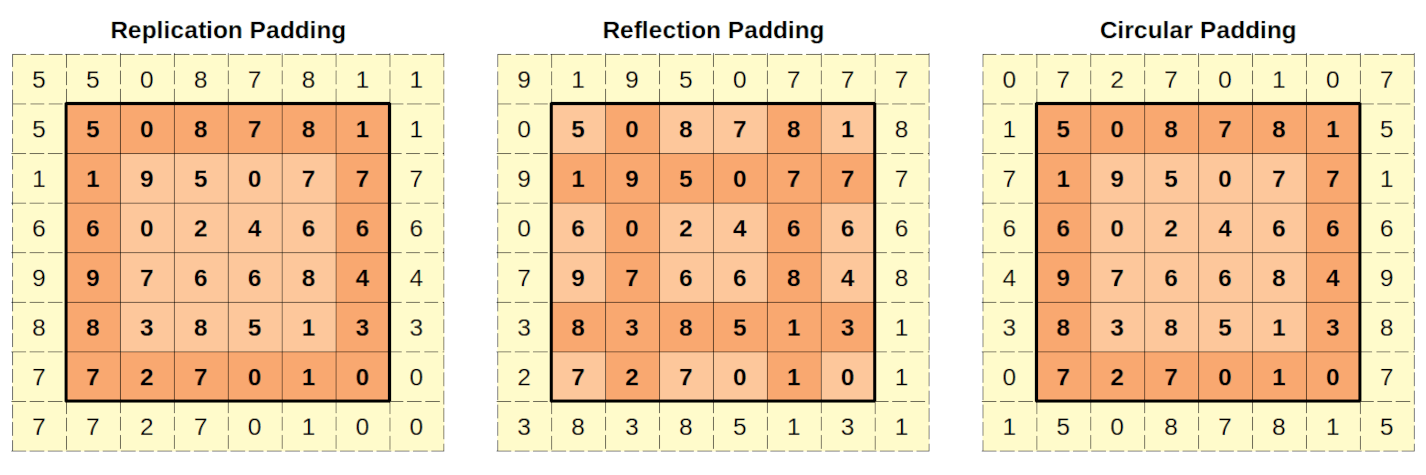

In [203]:
replication_padder = nn.ReplicationPad2d(padding=1)
replication_padder(image)

tensor([[[[5., 5., 0., 8., 7., 8., 1., 1.],
          [5., 5., 0., 8., 7., 8., 1., 1.],
          [1., 1., 9., 5., 0., 7., 7., 7.],
          [6., 6., 0., 2., 4., 6., 6., 6.],
          [9., 9., 7., 6., 6., 8., 4., 4.],
          [8., 8., 3., 8., 5., 1., 3., 3.],
          [7., 7., 2., 7., 0., 1., 0., 0.],
          [7., 7., 2., 7., 0., 1., 0., 0.]]]])

In [204]:
reflection_padder = nn.ReflectionPad2d(padding=1)
reflection_padder(image)

tensor([[[[9., 1., 9., 5., 0., 7., 7., 7.],
          [0., 5., 0., 8., 7., 8., 1., 8.],
          [9., 1., 9., 5., 0., 7., 7., 7.],
          [0., 6., 0., 2., 4., 6., 6., 6.],
          [7., 9., 7., 6., 6., 8., 4., 8.],
          [3., 8., 3., 8., 5., 1., 3., 1.],
          [2., 7., 2., 7., 0., 1., 0., 1.],
          [3., 8., 3., 8., 5., 1., 3., 1.]]]])

In [205]:
F.pad(image, pad=(1, 1, 1, 1), mode='replicate')

tensor([[[[5., 5., 0., 8., 7., 8., 1., 1.],
          [5., 5., 0., 8., 7., 8., 1., 1.],
          [1., 1., 9., 5., 0., 7., 7., 7.],
          [6., 6., 0., 2., 4., 6., 6., 6.],
          [9., 9., 7., 6., 6., 8., 4., 4.],
          [8., 8., 3., 8., 5., 1., 3., 3.],
          [7., 7., 2., 7., 0., 1., 0., 0.],
          [7., 7., 2., 7., 0., 1., 0., 0.]]]])

In [206]:
F.pad(image, pad=(1, 1, 1, 1), mode='reflect')

tensor([[[[9., 1., 9., 5., 0., 7., 7., 7.],
          [0., 5., 0., 8., 7., 8., 1., 8.],
          [9., 1., 9., 5., 0., 7., 7., 7.],
          [0., 6., 0., 2., 4., 6., 6., 6.],
          [7., 9., 7., 6., 6., 8., 4., 8.],
          [3., 8., 3., 8., 5., 1., 3., 1.],
          [2., 7., 2., 7., 0., 1., 0., 1.],
          [3., 8., 3., 8., 5., 1., 3., 1.]]]])

In [207]:
F.pad(image, pad=(1, 1, 1, 1), mode='circular')

tensor([[[[0., 7., 2., 7., 0., 1., 0., 7.],
          [1., 5., 0., 8., 7., 8., 1., 5.],
          [7., 1., 9., 5., 0., 7., 7., 1.],
          [6., 6., 0., 2., 4., 6., 6., 6.],
          [4., 9., 7., 6., 6., 8., 4., 9.],
          [3., 8., 3., 8., 5., 1., 3., 8.],
          [0., 7., 2., 7., 0., 1., 0., 7.],
          [1., 5., 0., 8., 7., 8., 1., 5.]]]])

<img src="https://drive.google.com/uc?export=view&id=1UqwSc_-3CNXX8U7SuwxkAgrOhhsequ_D" width="50%">

We're basically extending the original dimensions by **2p** pixels each.

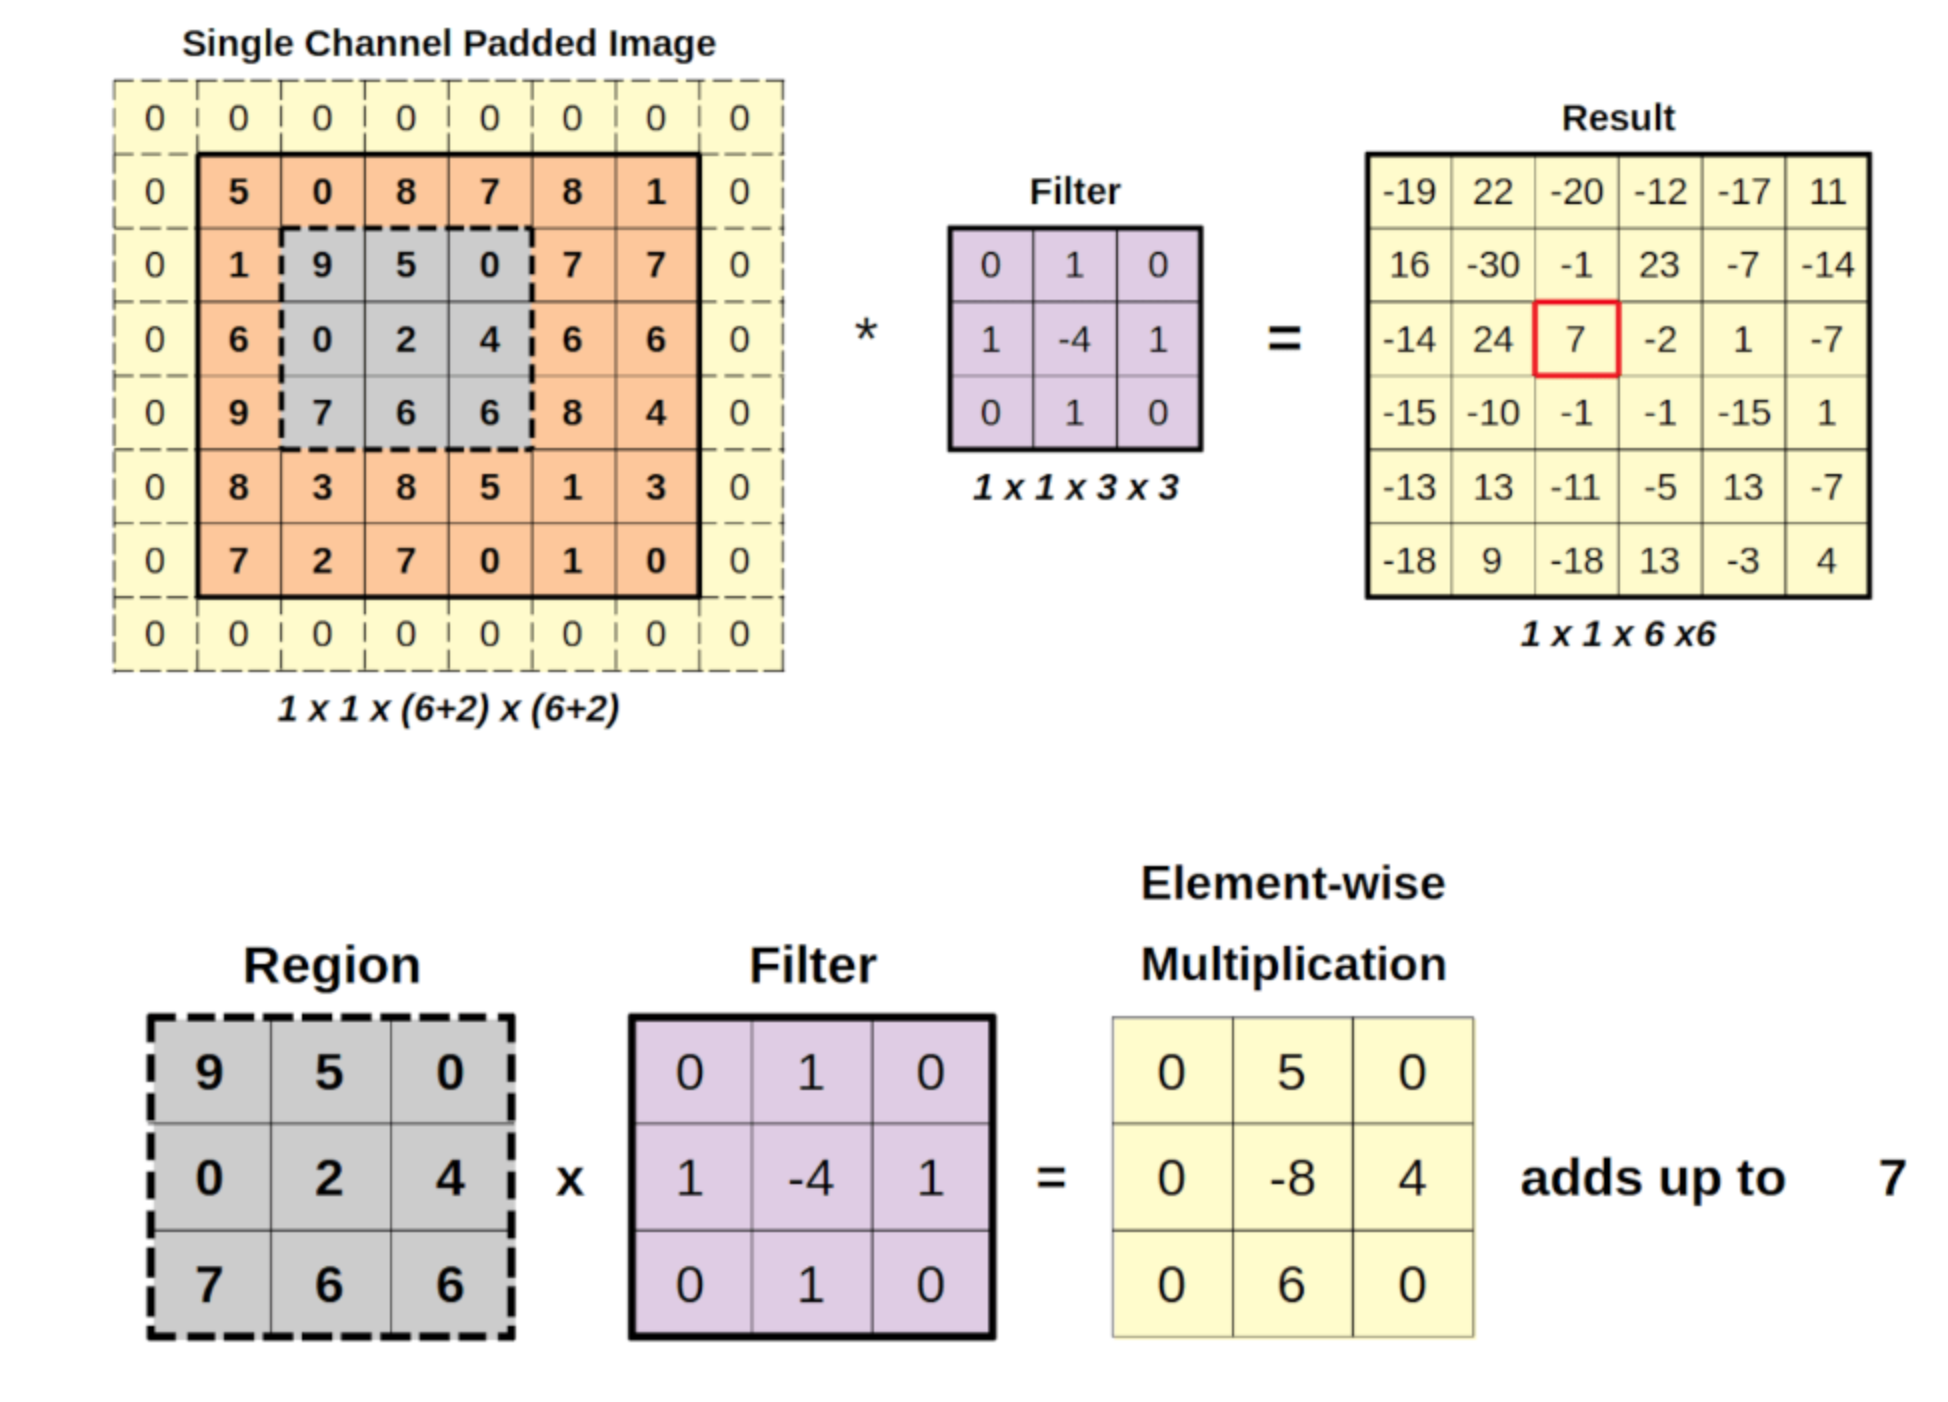

In [208]:
edge = np.array(
    [[[[0, 1, 0],
       [1, -4, 1],
       [0, 1, 0]]]]
)
kernel_edge = torch.as_tensor(edge).float()
kernel_edge.shape

padded = F.pad(image, (1, 1, 1, 1), mode='constant', value=0)
conv_padded = F.conv2d(padded, kernel_edge, stride=1)

In [209]:
conv_padded

tensor([[[[-19.,  22., -20., -12., -17.,  11.],
          [ 16., -30.,  -1.,  23.,  -7., -14.],
          [-14.,  24.,   7.,  -2.,   1.,  -7.],
          [-15., -10.,  -1.,  -1., -15.,   1.],
          [-13.,  13., -11.,  -5.,  13.,  -7.],
          [-18.,   9., -18.,  13.,  -3.,   4.]]]])

Pooling layers, they reduce the resolution of the network from the previous input layer, therefore fewer parameters in the lower layers.
- Faster computation
- it helps to prevent overfitting

There is also a ```padding``` option here.

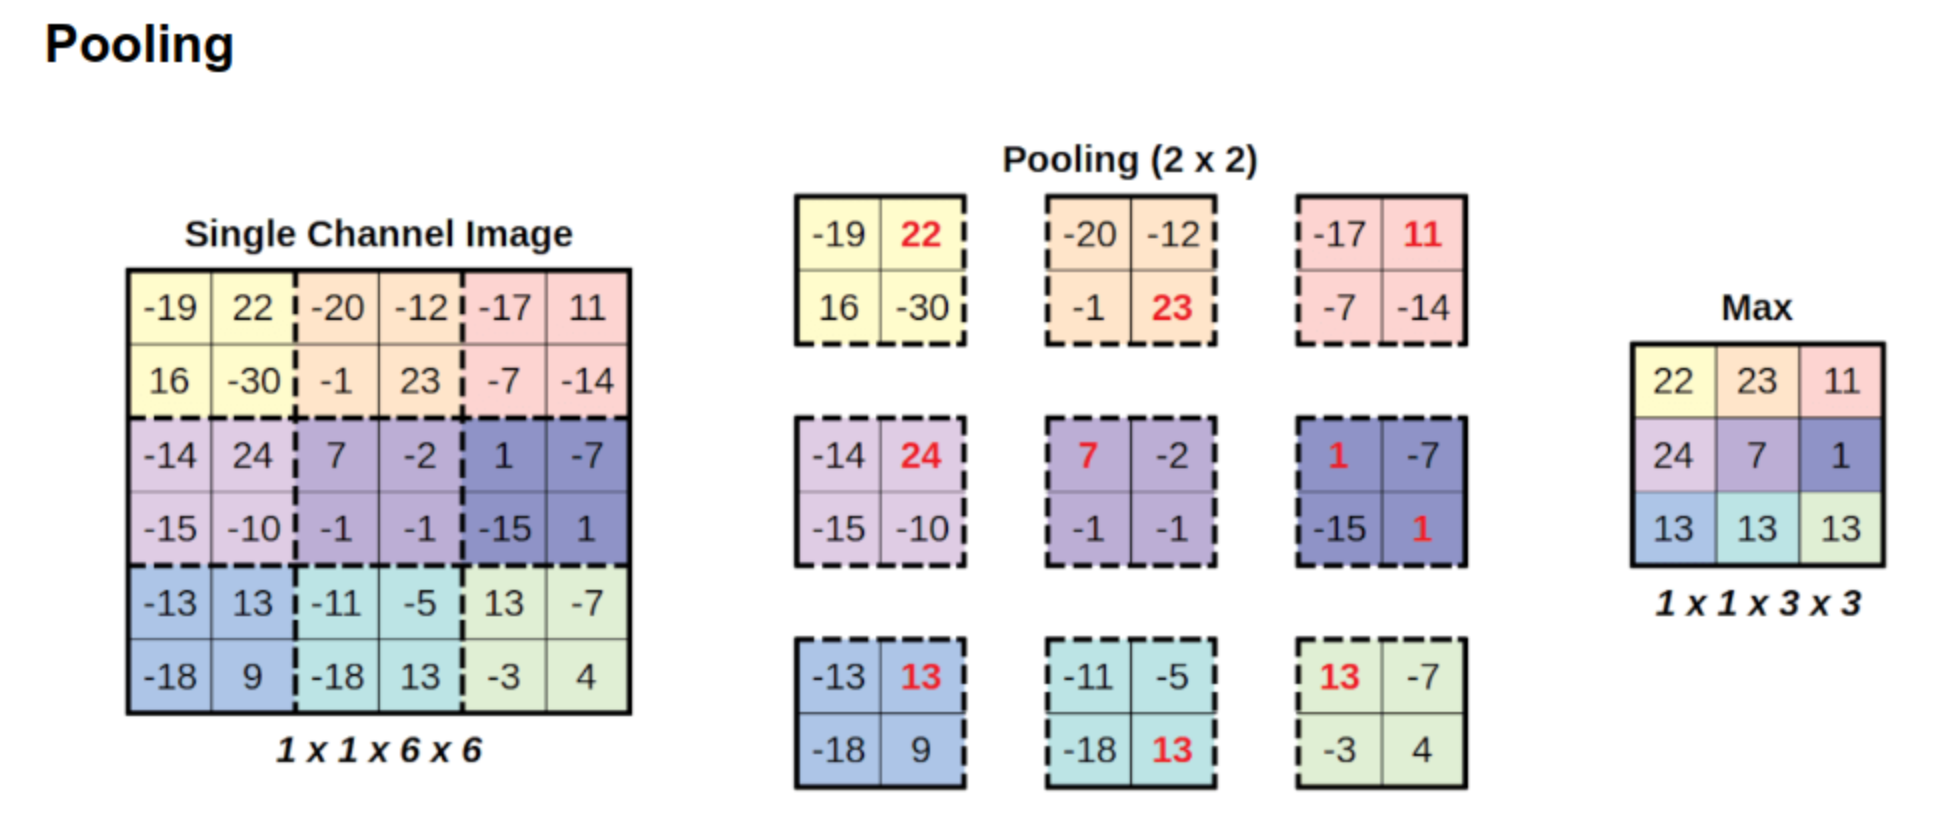

In [210]:
pooled = F.max_pool2d(conv_padded, kernel_size=2)
pooled

tensor([[[[22., 23., 11.],
          [24.,  7.,  1.],
          [13., 13., 13.]]]])

In [211]:
maxpool4 = nn.MaxPool2d(kernel_size=4)
pooled4 = maxpool4(conv_padded)
pooled4

tensor([[[[24.]]]])

## Let's start with convolutional neural networks

In [212]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convolution 1
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16,
                              kernel_size=3, stride=1, padding=0)
        self.relu1 = nn.ReLU()

        # Max pool 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        # Convolution 2
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32,
                              kernel_size=3, stride=1, padding=0)
        self.relu2 = nn.ReLU()

        # Max pool 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # Fully connected 1
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x, to_print=False):
        # Set 1
        if to_print:
          print('INPUT',x.shape)
        out = self.cnn1(x)
        if to_print:
          print('CNN1',out.shape)
        out = self.relu1(out)
        out = self.maxpool1(out)
        if to_print:
          print('MAXPOOL1',out.shape)

        # Set 2
        out = self.cnn2(out)
        if to_print:
          print('CNN2',out.shape)

        out = self.relu2(out)

        out = self.maxpool2(out)
        if to_print:
          print("after the 2nd maxpool:{} ".format(out.shape))
        # Flatten
        out = out.view(out.size(0), -1)
        if to_print:
          print("after the flatten:{} ".format(out.shape))
        out = self.fc1(out)
        if to_print:
          print('FINAL',out.shape)

        return out

In [213]:
## few changes to the train function used yesterday.

def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="cpu",to_print=False):
    model.to(device)
    for epoch in range(1, epochs+1):
        training_loss = 0.0
        valid_loss = 0.0
        model.train()
        for batch in train_loader:
            optimizer.zero_grad() # clear gradients for next train
            inputs, targets = batch
            inputs = inputs.to(device)
            targets = targets.to(device)
            output = model(inputs,to_print)
            loss = loss_fn(output, targets)
            loss.backward() # backpropagation, compute gradients
            optimizer.step() # apply gradients
            training_loss += loss.data.item() * inputs.size(0)
            # print(training_loss,loss.data.item(),inputs.size(0))
            if to_print:
              break
        training_loss /= len(train_loader.dataset)
        if to_print:
          break
        with torch.no_grad():
          model.eval()
          num_correct = 0
          num_examples = 0
          for batch in val_loader:
              inputs, targets = batch
              inputs = inputs.to(device)
              output = model(inputs)
              targets = targets.to(device)
              loss = loss_fn(output,targets)
              valid_loss += loss.data.item() * inputs.size(0)
              correct = torch.eq(torch.max(F.softmax(output, dim=1), dim=1)[1], targets)
              num_correct += torch.sum(correct).item()
              num_examples += correct.shape[0]
          valid_loss /= len(val_loader.dataset)

        print('Epoch: {}, Training Loss: {:.4f}, Validation Loss: {:.4f}, accuracy = {:.4f}'.format(epoch, training_loss,
        valid_loss, num_correct / num_examples))

In [214]:
cnn = CNN()
optimizer = optim.SGD(cnn.parameters(),lr=0.001)
train(cnn, optimizer,torch.nn.CrossEntropyLoss(), train_dl,val_dl, epochs=5)

RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [128, 784]

In [215]:
x_train_tensor.shape

torch.Size([50000, 784])

In [216]:
batch_size = 32
train_ds = TensorDataset(x_train_tensor.reshape(-1,1,28,28), y_train_tensor)
train_dl = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True)

val_ds = TensorDataset(x_val_tensor.reshape(-1,1,28,28), y_val_tensor)
val_dl = DataLoader(
    val_ds, batch_size=batch_size, shuffle=True)


test_ds = TensorDataset(x_test_tensor.reshape(-1,1,28,28), y_test_tensor)
test_dl = DataLoader(test_ds, batch_size=batch_size)

In [217]:
x_train_tensor.reshape(-1,1,28,28).shape

torch.Size([50000, 1, 28, 28])

In [218]:
cnn = CNN()
optimizer = optim.Adam(cnn.parameters(),lr=0.001)
train(cnn, optimizer,torch.nn.CrossEntropyLoss(), train_dl,val_dl, epochs=5, to_print=False)

Epoch: 1, Training Loss: 0.2392, Validation Loss: 0.0817, accuracy = 0.9760
Epoch: 2, Training Loss: 0.0806, Validation Loss: 0.0853, accuracy = 0.9765
Epoch: 3, Training Loss: 0.0639, Validation Loss: 0.0658, accuracy = 0.9818
Epoch: 4, Training Loss: 0.0560, Validation Loss: 0.0864, accuracy = 0.9801
Epoch: 5, Training Loss: 0.0473, Validation Loss: 0.0718, accuracy = 0.9832


In [219]:
import torch
import torchvision
import torchvision.transforms as transforms

In [220]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

In [221]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:04<00:00, 42.5MB/s]


# Recurrent Neural Networks

- CNNs don't have the concept of _memory_
- This is a crucial when we deal with data that have a temporal domain: a sequence of events: text, speech, video, time-series data, etc.
- The RNNs try to solve this problem with a *hidden state*
- We can imagine a RNN as a pipeline of fully connected layers network, where the succesive input being fed into the next layer in the sequence
- Then the error is back propagated through the RNN --> _vanishing gradient_
- A possible solution: Long Short-term Memory, a variant of RNN


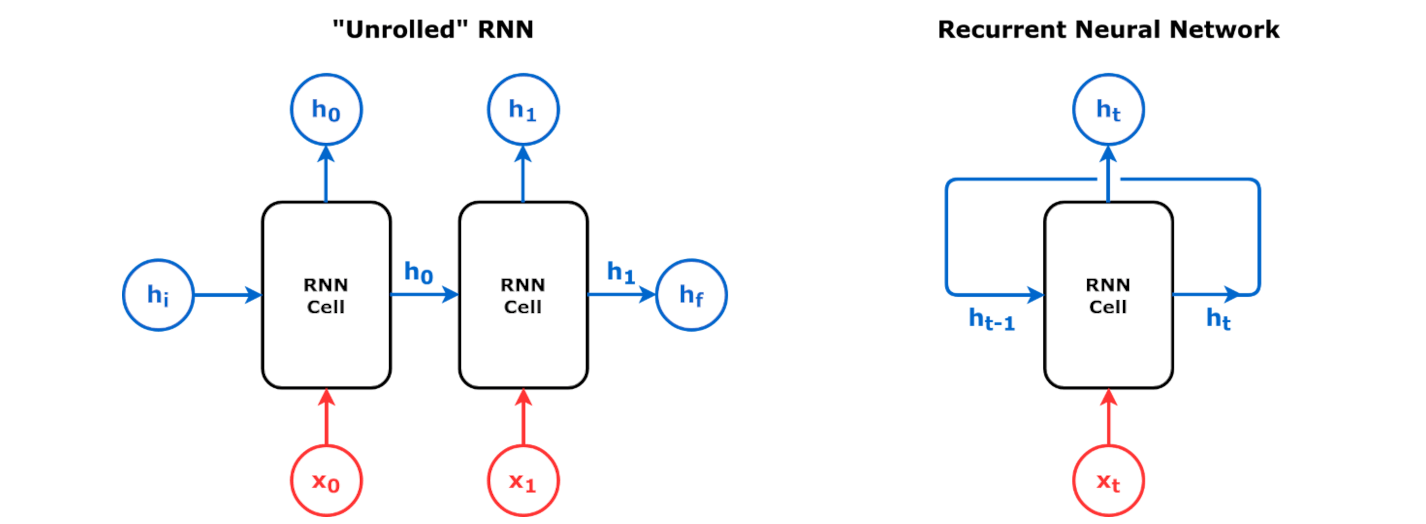
credits: Deep Learning with PyTorch Step-by-Step

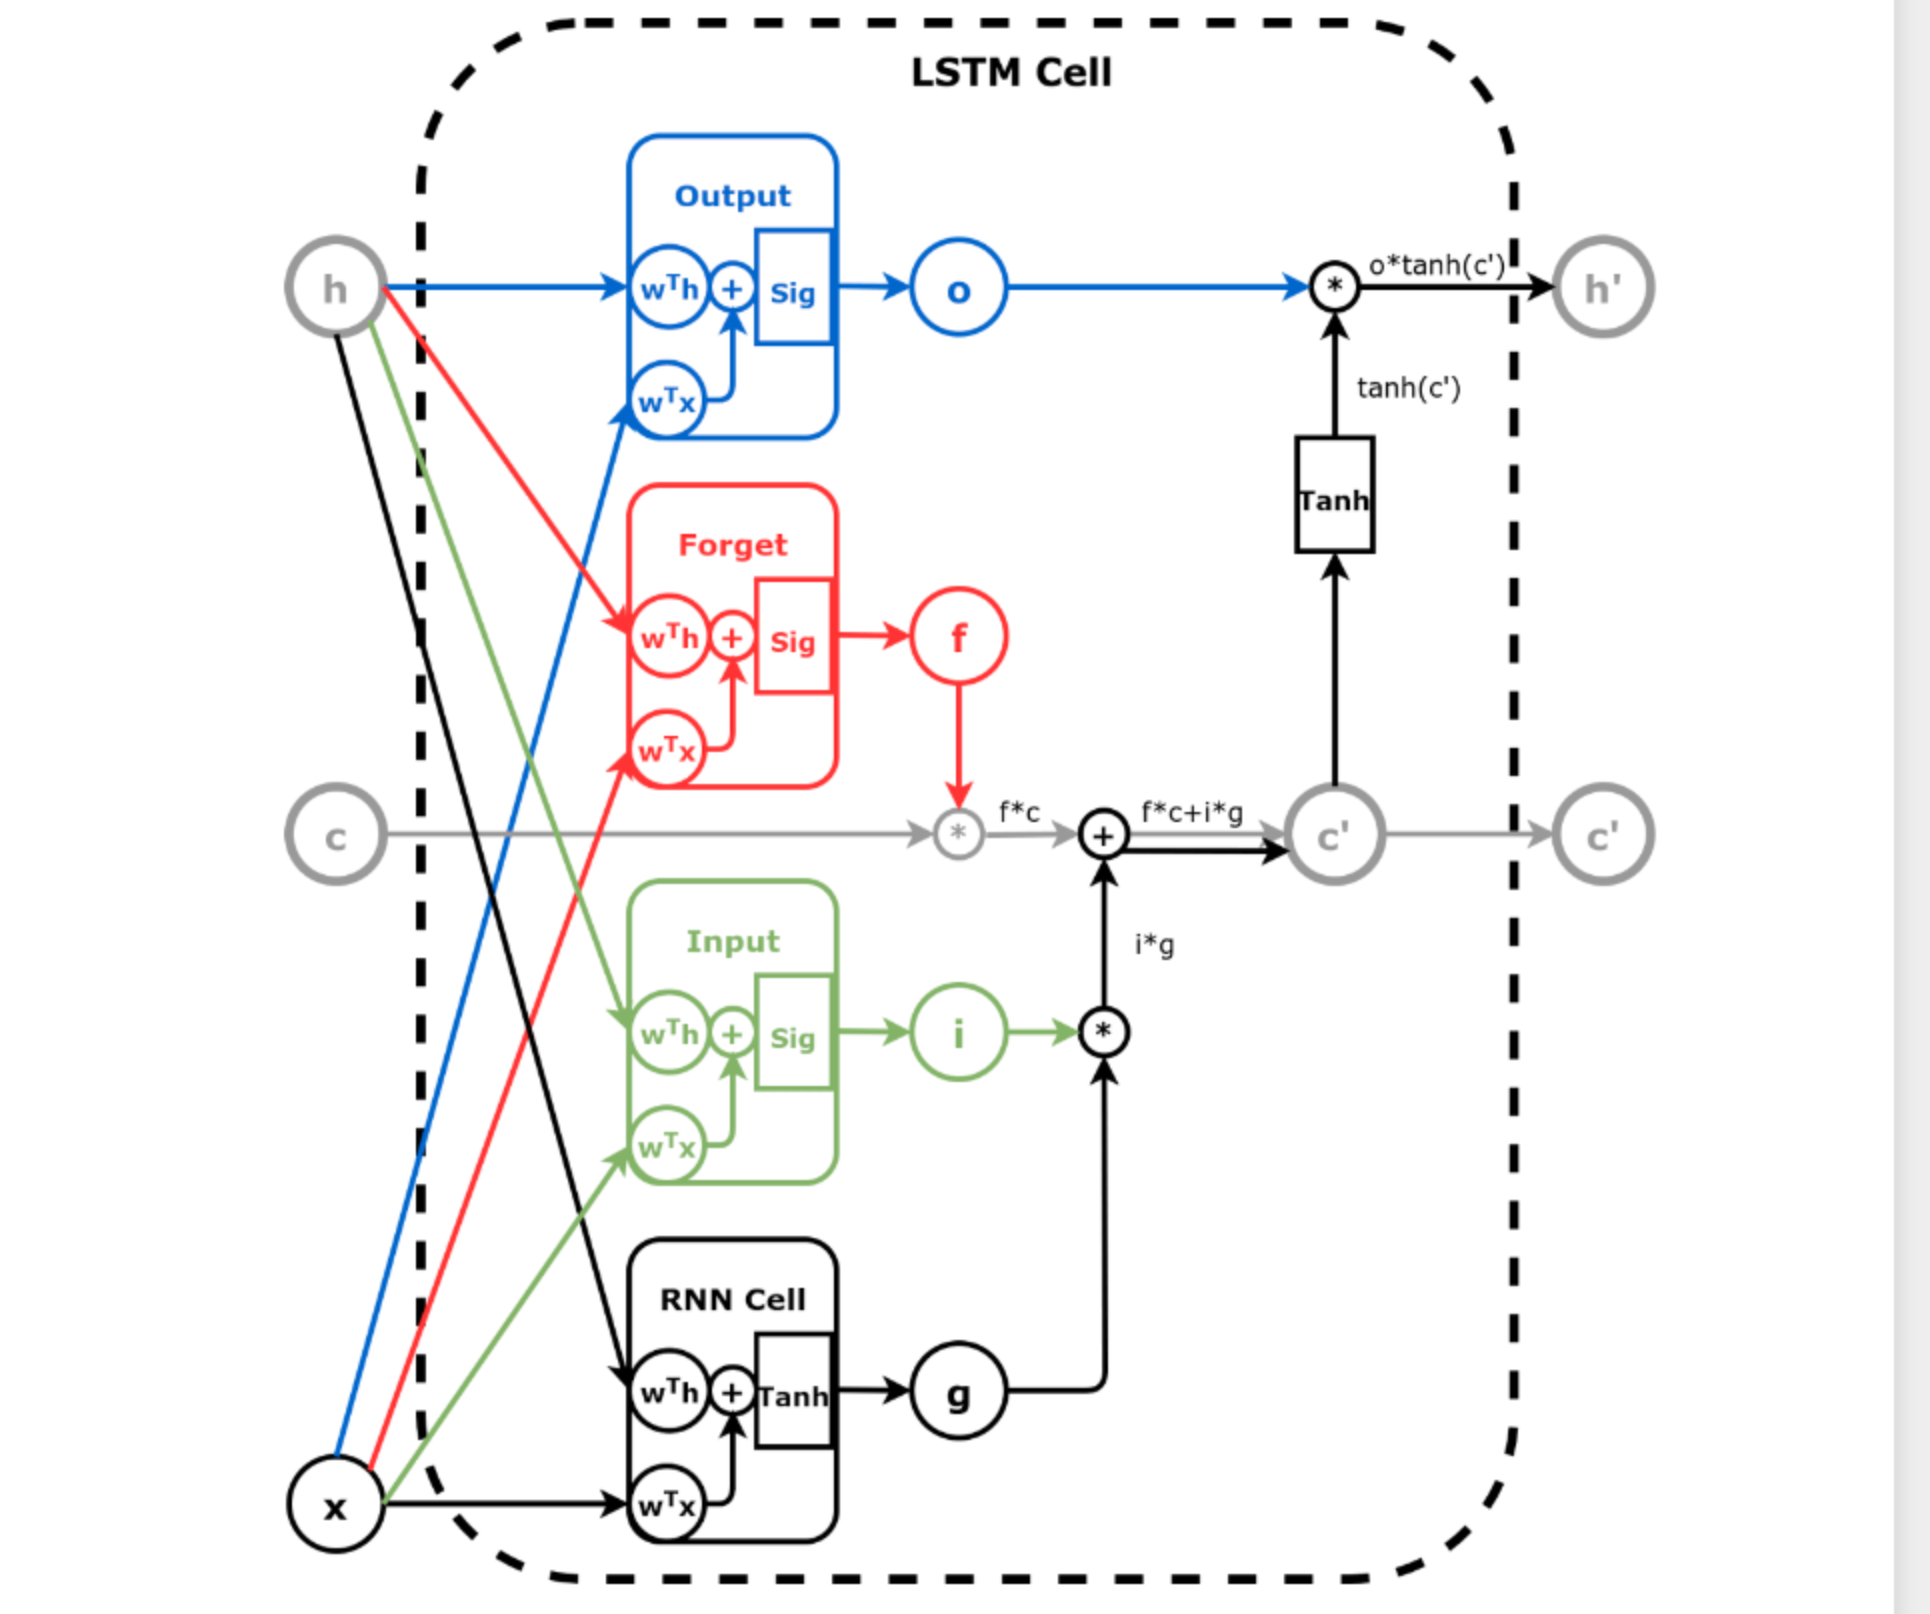

### Time-series
Let's try with LSTM applied to timeseries

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch
flight_data = sns.load_dataset("flights")
flight_data.head()

In [ ]:
plt.title('Month vs Passenger')
plt.ylabel('Total Passengers')
plt.xlabel('Months')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(flight_data['passengers'])

In [ ]:
all_data = flight_data['passengers'].values.astype(float)

test_data_size = 12

train_data = all_data[:-test_data_size]
test_data = all_data[-test_data_size:]

In [ ]:
print(len(train_data))
print(len(test_data))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
train_data_normalized = scaler.fit_transform(train_data .reshape(-1, 1))

In [ ]:
train_data_normalized = torch.FloatTensor(train_data_normalized).view(-1)


In [ ]:
train_window = 12

In [ ]:
'''
The function will accept the raw input data and will return a list of tuples.
In each tuple, the first element will contain list of 12 items corresponding
to the number of passengers traveling in 12 months, the second tuple element
will contain one item i.e. the number of passengers in the 12+1st month
'''

def create_inout_sequences(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L-tw):
        train_seq = input_data[i:i+tw]
        train_label = input_data[i+tw:i+tw+1]
        inout_seq.append((train_seq ,train_label))
    return inout_seq

In [ ]:
train_inout_seq = create_inout_sequences(train_data_normalized, train_window)


In [ ]:
print(train_inout_seq[0][0])
print(train_inout_seq[0][1])

In [ ]:
'''
input_size: Corresponds to the number of features in the input.
Though our sequence length is 12, for each month we have only
1 value i.e. total number of passengers, therefore the input size will be 1.
'''

'''
hidden_layer_size: Specifies the number of hidden layers along
with the number of neurons in each layer.
We will have one layer of 100 neurons.
'''

'''
output_size: The number of items in the output,
since we want to predict the number of passengers
for 1 month in the future, the output size will be 1.
'''

'''
Inside the forward method, the input_seq is passed as a parameter,
which is first passed through the lstm layer. The output of the lstm layer is
the hidden and cell states at current time step, along with the output.
The output from the lstm layer is passed to the linear layer.
The predicted number of passengers is stored in the last item of the
predictions list, which is returned to the calling function.
'''


class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=250, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size

        self.lstm = nn.LSTM(input_size, hidden_layer_size)

        self.linear = nn.Linear(hidden_layer_size, output_size)

        self.hidden_cell = (torch.zeros(1,1,self.hidden_layer_size),
                            torch.zeros(1,1,self.hidden_layer_size))

    def forward(self, input_seq):
        lstm_out, self.hidden_cell = self.lstm(input_seq.view(len(input_seq) ,1, -1), self.hidden_cell)
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]




In [ ]:
model = LSTM()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 300

for i in range(epochs):
    for seq, labels in train_inout_seq:
        optimizer.zero_grad()
        model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size),
                        torch.zeros(1, 1, model.hidden_layer_size))

        y_pred = model(seq)

        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()

    if i%25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')


In [ ]:
fut_pred = 12

test_inputs = train_data_normalized[-train_window:].tolist()

model.eval()

for i in range(fut_pred):
    seq = torch.FloatTensor(test_inputs[-train_window:])
    with torch.no_grad():
        model.hidden = (torch.zeros(1, 1, model.hidden_layer_size),
                        torch.zeros(1, 1, model.hidden_layer_size))
        test_inputs.append(model(seq).item())
test_inputs[fut_pred:]


In [ ]:
actual_predictions = scaler.inverse_transform(np.array(test_inputs[train_window:] ).reshape(-1, 1))
print(actual_predictions)

In [ ]:
x = np.arange(132, 144, 1)
print(x)

In [ ]:
plt.title('Month vs Passenger')
plt.ylabel('Total Passengers')
plt.grid(True)
plt.autoscale(axis='x', tight=True)
plt.plot(flight_data['passengers'])
plt.plot(x,actual_predictions)
plt.show()

## Text Analysis --> Sentiment Analysis
## Text Analysis --> Next word prediction

In [ ]:
for i in range(0,10):
  sentiment = classify_tweet(test[i].tweet)
  print(test[i].tweet,test[i].label,sentiment,)

In [ ]:
test[0].tweet

In [ ]:
def classify_tweet(tweet):
    categories = {0: "Negative", 1:"Positive"}
    processed = TWEET.process([TWEET.preprocess(tweet)])
    processed = processed.to(device)
    model.eval()
    return categories[model(processed).argmax().item()]

In [ ]:
model.to(device)
with torch.no_grad():
  model.eval()
  for batch in test_iterator:
    outputs = model(batch.tweet.to(device))

In [ ]:
device = 'cpu'

In [ ]:

# !pip install -U torch==1.8.0 torchtext==0.9.0

In [ ]:

import torchtext
from torchtext import data
import pandas as pd

In [ ]:
torchtext.__version__

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
tweetsDF = pd.read_csv('/content/drive/Shareddrives/MD2SL-material/data/training.1600000.processed.noemoticon.csv',encoding='latin1',engine='python',header=None)

In [ ]:
tweetsDF.head()

In [ ]:
tweetsDF[0].value_counts()


In [ ]:

tweetsDF.columns

In [ ]:
tweetsDF["sentiment_cat"] = tweetsDF[0].astype('category')
tweetsDF["sentiment_cat"].cat.codes

In [ ]:
tweetsDF["sentiment"] = tweetsDF["sentiment_cat"].cat.codes
tweetsDF.to_csv("train-processed.csv", header=None, index=None)
tweetsDF.sample(10000).to_csv("train-processed-sample.csv", header=None, index=None)


```torchtext``` takes a straigthforward approach to generating datasets, but you need to define the _fields_.
The class ```Fields``` is what we need to use, it could take several parameters, give a look to the documentation:
[Class Field documentation](https://pytorch.org/text/_modules/torchtext/data/field.html)

In [ ]:
LABEL = data.Field() #a subclass of Field that sets sequential to False
TWEET = data.Field('spacy', tokenizer_language='en_core_web_sm', lower=True)

fields = [('score',None), ('id',None), ('date',None), ('query',None),
          ('name',None), ('tweet', TWEET), ('category',None), ('label',LABEL)]

This is then passed to the TabularDataset with all the fields we need

In [ ]:
twitterDataset = data.dataset.TabularDataset(
        path="train-processed-sample.csv",
        format="CSV",
        fields=fields,
        skip_header=False)

In [ ]:

(train, test, valid) = twitterDataset.split(split_ratio=[0.8,0.1,0.1],
                                            stratified=True, strata_field='label')

(len(train),len(test),len(valid))

In [ ]:

vocab_size = 20000
# torchtext is building for us the one_hot_encoding for the words
TWEET.build_vocab(train, max_size = vocab_size)
LABEL.build_vocab(train)
TWEET.vocab.freqs.most_common(10)

In [ ]:
print('How big is our vocabolary? {}'.format(len(TWEET.vocab)))

#1 for unk
#2 for padding, a padding token that will be used to pad all our to roughly the same sie

In [ ]:
'''
torchtext provides the BucketIterator method that will produce what it calls a
batch. Similar to the data loader we used before
'''


train_iterator, valid_iterator, test_iterator = data.BucketIterator.splits(
    (train, valid, test),
    batch_size = 32,
    device = device,
    sort_key = lambda x: len(x.tweet),
    sort_within_batch = False)

In [ ]:
class OurFirstLSTM(nn.Module):
    def __init__(self, hidden_size, embedding_dim, vocab_size):
        super(OurFirstLSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.encoder = nn.LSTM(input_size=embedding_dim,
                hidden_size=hidden_size, num_layers=1)
        self.predictor = nn.Linear(hidden_size, 2)

    def forward(self, seq):
        output, (hidden,_) = self.encoder(self.embedding(seq))
        preds = self.predictor(hidden.squeeze(0))
        return preds



3 layers:
- the words of our tweet are pushed in ```Embeddings``` layer, with 300-dimensional vector
- then fed into a LSTM with 100 hidden features
- standard fully connected layer with 3 outputs corresponding to our three possible classes

In [ ]:
def train(epochs, model, optimizer, criterion, train_iterator, valid_iterator):
    for epoch in range(1, epochs+1):

        training_loss = 0.0
        valid_loss = 0.0
        model.train()
        for batch_idx, batch in enumerate(train_iterator):
            optimizer.zero_grad()
            predict = model(batch.tweet) ##we need to specify which field
            loss = criterion(predict,batch.label)
            loss.backward()
            optimizer.step()
            training_loss += loss.data.item() * batch.tweet.size(0)
        training_loss /= len(train_iterator)

        with torch.no_grad():
          model.eval()
          for batch_idx,batch in enumerate(valid_iterator):
              predict = model(batch.tweet)
              loss = criterion(predict,batch.label)
              valid_loss += loss.data.item() * batch.tweet.size(0)
          valid_loss /= len(valid_iterator)
          print('Epoch: {}, Training Loss: {:.2f}, Validation Loss: {:.2f}'.format(epoch, training_loss, valid_loss))

In [ ]:
model = OurFirstLSTM(100,300, 20002)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

train(5, model, optimizer, criterion, train_iterator, valid_iterator)

In [ ]:
'''
torchtext doesn't help when we want to predict
We need to emulate the preprocessing pipeline, and make the prediction on the
output of that pipeline
'''

def classify_tweet(tweet,device='cpu'):
    '''
    preprocess performs the tokenization,
    then we call process on the resulting
    tokens to obtain a tensor based on our already built vocabulary
    '''
    model.to(device)
    categories = {0: "Negative", 1:"Positive"}
    processed = TWEET.process([TWEET.preprocess(tweet)])
    processed = processed.float().to(device)
    print(processed)
    model.eval()
    return categories[model(processed).argmax().item()]